# IMPORTING LIBRARIES

In [2]:
!pip install ChannelAttribution

In [3]:
import ChannelAttribution as ca

*** Looking to run more advanced attribution? Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info.
Version: 2.2.5


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

plt.style.use('default')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# LOADING DATASETS

In [6]:
touchpoints = pd.read_csv("touchpoints.csv")
profiles = pd.read_csv("user_profiles.csv")
campaigns = pd.read_csv("campaign_spend.csv")


In [7]:
print("Touchpoints:", touchpoints.shape)
print("Profiles:", profiles.shape)
print("Campaigns:", campaigns.shape)

Touchpoints: (566510, 5)
Profiles: (100000, 4)
Campaigns: (50, 6)


In [8]:
touchpoints.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type
0,U_B01_00000,1/1/2026 19:27,CMP_B01_INF_899,Influencer Blog,Impression
1,U_B01_00001,1/1/2026 20:37,CMP_B01_GOO_434,Google Search,Impression
2,U_B01_00001,1/1/2026 20:38,CMP_B01_GOO_434,Google Search,Click
3,U_B01_00001,1/4/2026 15:37,CMP_B01_MAR_127,Marketplace,Impression
4,U_B01_00001,1/6/2026 8:37,CMP_B01_INS_285,Instagram,Impression


In [9]:
touchpoints.info()

<class 'pandas.DataFrame'>
RangeIndex: 566510 entries, 0 to 566509
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   User_ID      566510 non-null  str  
 1   Timestamp    566510 non-null  str  
 2   Campaign_ID  566510 non-null  str  
 3   Channel      566510 non-null  str  
 4   Event_Type   566510 non-null  str  
dtypes: str(5)
memory usage: 53.9 MB


In [10]:
profiles.head()

,User_ID,Segment,Trend_Affinity,Geography
0,U_B01_00000,Fitness Enthusiast,Sustainable Packaging,Tier 1
1,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1
2,U_B01_00002,Gen-Z Trendseeker,Sustainable Packaging,Tier 1
3,U_B01_00003,Premium Gourmet,Value-Pack,Tier 3
4,U_B01_00004,Gen-Z Trendseeker,Value-Pack,Tier 2


In [11]:
profiles.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   User_ID         100000 non-null  str  
 1   Segment         100000 non-null  str  
 2   Trend_Affinity  100000 non-null  str  
 3   Geography       100000 non-null  str  
dtypes: str(4)
memory usage: 7.2 MB


In [12]:
campaigns.head()

,Campaign_ID,Brand_ID,Channel,Pricing_Model,Cost_Rate_INR,Total_Budget_Allocated
0,CMP_B01_INS_285,B01,Instagram,CPM,391.98,613144.27
1,CMP_B01_GOO_434,B01,Google Search,CPC,23.41,27896859.25
2,CMP_B01_INF_899,B01,Influencer Blog,CPM,329.34,14499430.43
3,CMP_B01_YOU_211,B01,YouTube,CPM,180.36,19807806.26
4,CMP_B01_MAR_127,B01,Marketplace,CPC,37.54,37182759.79


In [13]:
campaigns.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Campaign_ID             50 non-null     str    
 1   Brand_ID                50 non-null     str    
 2   Channel                 50 non-null     str    
 3   Pricing_Model           50 non-null     str    
 4   Cost_Rate_INR           50 non-null     float64
 5   Total_Budget_Allocated  50 non-null     float64
dtypes: float64(2), str(4)
memory usage: 4.0 KB


# DATA QUALITY CHECK

In [15]:
# ==========================================================
# DATA QUALITY CHECK
# ==========================================================
#
# Before building the Markov model, we verify:
#
# 1. Missing values
# 2. Duplicate rows
# 3. Event type distribution
# 4. Channel distribution
#
# This ensures that customer journey construction
# is based on clean and reliable data.
# ==========================================================

print("\nMissing Values\n")
print(touchpoints.isnull().sum())

print("\nDuplicate Rows\n")
print(touchpoints.duplicated().sum())

print("\nEvent Type Distribution\n")
print(touchpoints["Event_Type"].value_counts())

print("\nChannel Distribution\n")
print(touchpoints["Channel"].value_counts())


Missing Values

User_ID        0
Timestamp      0
Campaign_ID    0
Channel        0
Event_Type     0
dtype: int64

Duplicate Rows

0

Event Type Distribution

Event_Type
Impression     439694
Click          118191
Purchase         5498
Add-to-Cart      3127
Name: count, dtype: int64

Channel Distribution

Channel
Google Search      115239
Instagram          113529
Marketplace        112947
Influencer Blog    112417
YouTube            112378
Name: count, dtype: int64


In [16]:
#The touchpoints dataset demonstrates high data quality with no missing
#values, no duplicate records, and a balanced distribution of channel
#interactions.

#The event distribution follows a realistic customer journey funnel,
#providing a reliable foundation for bot detection, customer path
#construction, and subsequent Markov attribution analysis.

# CONVERTING TIMESTAMP TO DATETIME FORMAT

In [18]:
touchpoints["Timestamp"].dtype

<StringDtype(na_value=nan)>

In [19]:
touchpoints["Timestamp"] = pd.to_datetime(
    touchpoints["Timestamp"]
)

In [20]:
touchpoints["Timestamp"].dtype

dtype('<M8[us]')

In [21]:
touchpoints["Timestamp"].head()

0   2026-01-01 19:27:00
1   2026-01-01 20:37:00
2   2026-01-01 20:38:00
3   2026-01-04 15:37:00
4   2026-01-06 08:37:00
Name: Timestamp, dtype: datetime64[us]

In [24]:
# ==========================================================
# DATASET TIME RANGE
# ==========================================================

print("Start Date:", touchpoints["Timestamp"].min())
print("End Date  :", touchpoints["Timestamp"].max())

print(
    "Duration (Days):",
    (
        touchpoints["Timestamp"].max()
        -
        touchpoints["Timestamp"].min()
    ).days
)

Start Date: 2026-01-01 08:00:00
End Date  : 2026-05-17 17:57:00
Duration (Days): 136


In [25]:
# ==========================================================
# DAILY TOUCHPOINT TREND
# ==========================================================

daily_activity = (
    touchpoints
    .groupby(
        touchpoints["Timestamp"].dt.date
    )
    .size()
)

daily_activity.head()

Timestamp
2026-01-01    109134
2026-01-02     31624
2026-01-03     48326
2026-01-04     50575
2026-01-05     36023
dtype: int64

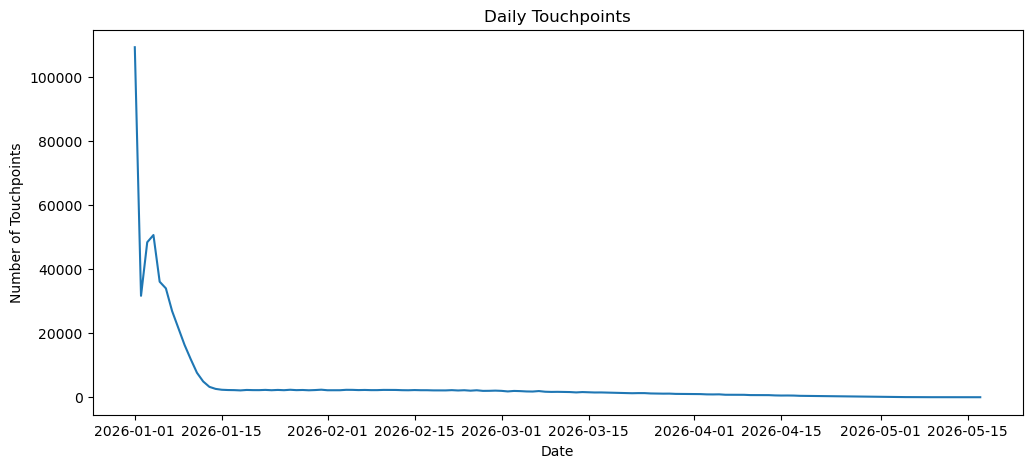

In [26]:
plt.figure(figsize=(12,5))

daily_activity.plot()

plt.title("Daily Touchpoints")
plt.xlabel("Date")
plt.ylabel("Number of Touchpoints")

plt.show()

In [27]:
# ==========================================================
# MONTHLY EVENTS
# ==========================================================

touchpoints["Month"] = (
    touchpoints["Timestamp"]
    .dt.to_period("M")
)

monthly_events = (
    touchpoints
    .groupby("Month")
    .size()
)

monthly_events

Month
2026-01    442709
2026-02     61047
2026-03     46092
2026-04     16128
2026-05       534
Freq: M, dtype: int64

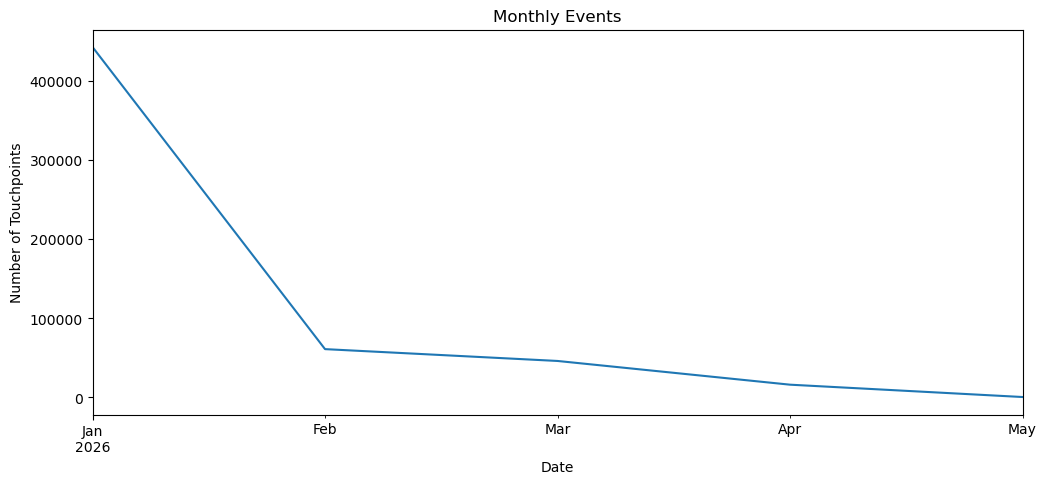

In [28]:
plt.figure(figsize=(12,5))

monthly_events.plot()

plt.title("Monthly Events")
plt.xlabel("Date")
plt.ylabel("Number of Touchpoints")

plt.show()

In [29]:
# ==========================================================
# INTERPRETATION
# ==========================================================
#
# • Timestamp conversion was successful, allowing
#   time-based analysis of user interactions.
#
# • The dataset spans from 01-Jan-2026 to 17-May-2026
#   (~136 days of campaign activity).
#
# • Daily touchpoints show a very high spike at the
#   beginning of January, followed by a sharp decline
#   and then a relatively stable trend.
#
# • Monthly analysis indicates that January contributed
#   the majority of touchpoints, with activity gradually
#   decreasing in subsequent months.
#
# • This suggests that campaign engagement was strongest
#   during the initial launch period and declined over time,
#   which is a common pattern in digital marketing campaigns.
# ==========================================================

# EXPLORATORY DATA ANALYSIS( BOTS ARE NOT REMOVED YET )

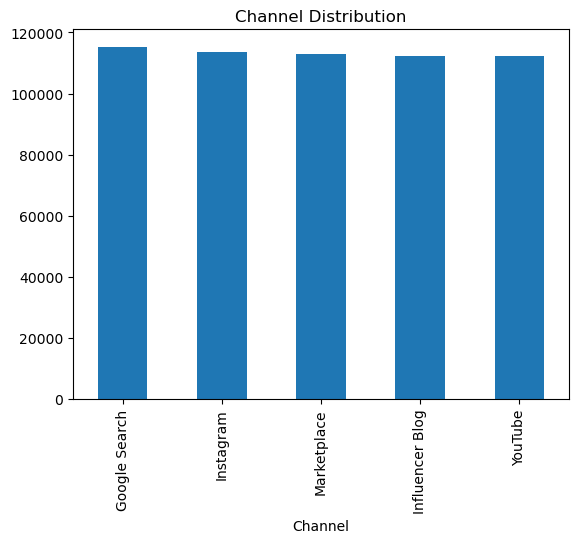

In [31]:
touchpoints["Channel"].value_counts().plot(
    kind="bar"
)

plt.title("Channel Distribution")
plt.show()

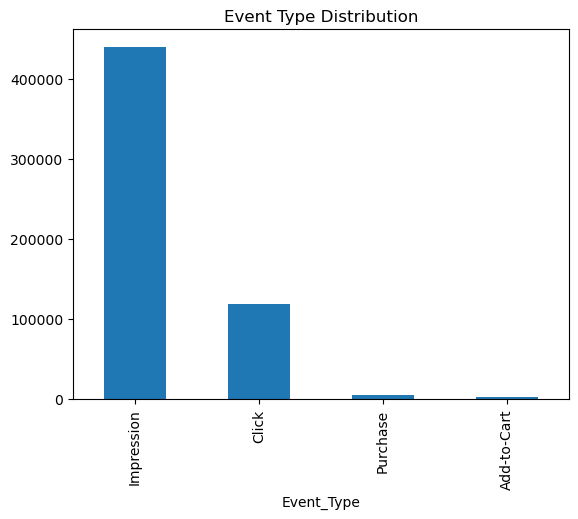

In [32]:
touchpoints["Event_Type"].value_counts().plot(
    kind="bar"
)

plt.title("Event Type Distribution")
plt.show()

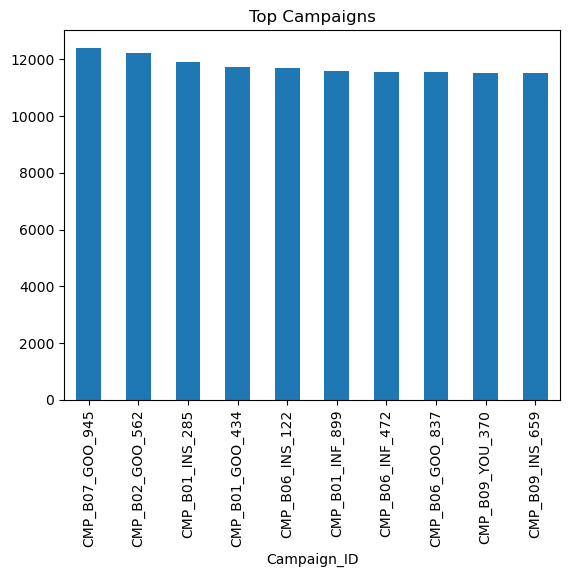

In [33]:
touchpoints["Campaign_ID"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Campaigns")
plt.show()

In [34]:
campaigns.groupby('Channel')['Total_Budget_Allocated'].sum()

Channel
Google Search      2.029821e+08
Influencer Blog    1.148977e+08
Instagram          1.941355e+08
Marketplace        2.405746e+08
YouTube            2.660160e+08
Name: Total_Budget_Allocated, dtype: float64

In [35]:
pd.crosstab(
    touchpoints['Channel'],
    touchpoints['Event_Type']
)

Event_Type,Add-to-Cart,Click,Impression,Purchase
Channel,,,,
Google Search,619,23718,88241,2661
Influencer Blog,639,23518,87759,501
Instagram,638,23844,88174,873
Marketplace,601,23482,87840,1024
YouTube,630,23629,87680,439


In [36]:
#CONVERSION RATE OF THE TOUCHPOINTS DATASET WHERE BOTS WERE INCLUDED 
channel_events = pd.crosstab(
    touchpoints['Channel'],
    touchpoints['Event_Type']
)

In [37]:
channel_events['Simple_Conversion_Rate'] = (
    channel_events['Purchase']
    /
    channel_events.sum(axis=1)
)*100
print(channel_events)

Event_Type       Add-to-Cart  Click  Impression  Purchase  \
Channel                                                     
Google Search            619  23718       88241      2661   
Influencer Blog          639  23518       87759       501   
Instagram                638  23844       88174       873   
Marketplace              601  23482       87840      1024   
YouTube                  630  23629       87680       439   

Event_Type       Simple_Conversion_Rate  
Channel                                  
Google Search                  2.309114  
Influencer Blog                0.445662  
Instagram                      0.768967  
Marketplace                    0.906620  
YouTube                        0.390646  


In [38]:
# ==========================================================
# INTERPRETATION
# ==========================================================
#
# • Channel distribution is nearly balanced across all five
#   marketing channels, with each channel contributing
#   approximately 112k–115k touchpoints.
#
# • Impression events dominate the dataset, followed by
#   Clicks, while Add-to-Cart and Purchase events form a
#   much smaller proportion of total interactions.
#
# • This indicates a typical marketing funnel where many
#   users are exposed to campaigns, fewer engage through
#   clicks, and only a small fraction complete purchases.
#
# • The top campaigns have very similar touchpoint volumes,
#   suggesting that campaign exposure was distributed fairly
#   evenly across brands and channels.
#
# • Google Search generated the highest number of purchases
#   (2661) and achieved the highest simple conversion rate
#   (~2.31%), indicating strong conversion efficiency.
#
# • Marketplace and Instagram show moderate conversion
#   performance, while Influencer Blog and YouTube have
#   comparatively lower direct conversion rates.
#
# • Since bots have not yet been removed, these conversion
#   rates represent raw performance and may change slightly
#   after data cleaning and bot filtering.
# ==========================================================

# FRAUD DETECTION( BOT TRAFFIC )

In [40]:
# SORTING THE DATASET BY USER ACCORDING TO THEIR TIMESTAMP
touchpoints.sort_values(
    ['User_ID','Timestamp']
)

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,Month
0,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression,2026-01
1,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression,2026-01
2,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click,2026-01
3,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression,2026-01
4,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression,2026-01
...,...,...,...,...,...,...
566505,U_B10_09998,2026-01-06 21:01:00,CMP_B10_MAR_943,Marketplace,Impression,2026-01
566506,U_B10_09998,2026-01-08 01:01:00,CMP_B10_INS_931,Instagram,Impression,2026-01
566507,U_B10_09999,2026-01-01 19:50:00,CMP_B10_INS_931,Instagram,Impression,2026-01
566508,U_B10_09999,2026-01-03 17:50:00,CMP_B10_YOU_857,YouTube,Impression,2026-01


In [41]:
# VERIFYING WHETHER THE TOUCHPOINTS DATA SORTED OR NOT
touchpoints.groupby("User_ID")["Timestamp"].apply(lambda x: x.is_monotonic_increasing).all()

np.True_

In [42]:
# DESCRIPTION OF USERS IN TOUCHPOINT DATASET
user_touchpoints = (
    touchpoints.groupby('User_ID')
    .size()
)


In [43]:
user_touchpoints.describe()

count    100000.000000
mean          5.665100
std          13.754565
min           1.000000
25%           2.000000
50%           4.000000
75%           5.000000
max         140.000000
dtype: float64

In [44]:
# BASICALLY ONE METHOD FINDING OUTLIERS IS MAXIMUM VALUE SHOULD NOT BE MORE THAN  mean + 3*standard deviation
# BUT MAX VALUE EXCEEDS THE THRESOLD VALUE.
mean_tp = user_touchpoints.mean()

std_tp = user_touchpoints.std()

threshold = mean_tp + 3 * std_tp

threshold

np.float64(46.928794512672475)

In [45]:
# ALSO HERE WE CAN OBSERVE THAT AFTER 13 TOUCHPOINTS PER USER, THE TOUCHPOINTS DIRECTLY JUMPED TO [60,140] PER USER WHICH SEEMS SUSPICIOUS
user_touchpoints.value_counts().sort_index()

1      14759
2      15086
3      15175
4      15410
5      15141
6      15078
7       5400
8       1582
9        341
10        63
11        11
12         1
13         1
60        46
62        56
64        43
66        47
68        47
70        45
72        52
74        57
76        42
78        55
80        46
82        45
84        44
86        45
88        49
90        55
92        57
94        43
96        57
98        61
100       43
102       47
104       50
106       54
108       53
110       43
112       42
114       45
116       37
118       34
120       44
122       47
124       46
126       43
128       45
130       57
132       52
134       56
136       41
138       35
140       46
Name: count, dtype: int64

In [46]:
# ==========================================================
# BOT DETECTION STEP 1 
# ==========================================================
# IF WE SET THIS CONDITON WHERE TOUCHPOINTS>50 THEN ALSO 1952 USERS SEEMED SUSPICIOUS WHICH IS EQUAL COMPARING WITH THE THESOLD VALUE
(user_touchpoints >= 50).sum()

np.int64(1952)

In [47]:
suspicious_users = user_touchpoints[
    user_touchpoints > threshold
].index

In [48]:
len(suspicious_users)

1952

In [49]:
# NOW LETS DESCRIBE THESE SUSPICIOUS USERS
high_touch_users = user_touchpoints[
    user_touchpoints >= 50
]

high_touch_users.describe()

count    1952.000000
mean       99.354508
std        23.507795
min        60.000000
25%        78.000000
50%        98.000000
75%       120.000000
max       140.000000
dtype: float64

In [50]:
# NOW LETS CHECK THE EVENT TYPE THESE USERS HAVE GONE THROUGH
high_touch_ids = high_touch_users.index
touchpoints[
    touchpoints['User_ID'].isin(high_touch_ids)
]['Event_Type'].value_counts()
# 

Event_Type
Impression    96970
Click         96970
Name: count, dtype: int64

In [51]:
# HERE THE 1952 USERS CONTRIBUTED ALMSOT 34-35% OF THE TOUCHPOINT DATASET WHICH AFFECTS THE CONVERSION RATE ALSO
touchpoints['Bot_Flag'] = (
    touchpoints['User_ID']
    .isin(suspicious_users)
)
touchpoints['Bot_Flag'].value_counts()

Bot_Flag
False    372570
True     193940
Name: count, dtype: int64

In [52]:
# Total users
total_users = touchpoints["User_ID"].nunique()

# Suspicious users
suspicious_users_count = len(suspicious_users)

# Percentage of suspicious users
suspicious_user_pct = (
    suspicious_users_count
    / total_users
) * 100

# Touchpoint contribution
bot_touchpoints = touchpoints["Bot_Flag"].value_counts()[True]

normal_touchpoints = touchpoints["Bot_Flag"].value_counts()[False]

total_touchpoints = len(touchpoints)

bot_touchpoint_pct = (
    bot_touchpoints
    / total_touchpoints
) * 100

print("Total Users:", total_users)
print("Suspicious Users:", suspicious_users_count)
print("Suspicious User %:", round(suspicious_user_pct,2))

print()

print("Normal Touchpoints:", normal_touchpoints)
print("Bot Touchpoints:", bot_touchpoints)
print("Total Touchpoints:", total_touchpoints)
print("Bot Touchpoint %:", round(bot_touchpoint_pct,2))

Total Users: 100000
Suspicious Users: 1952
Suspicious User %: 1.95

Normal Touchpoints: 372570
Bot Touchpoints: 193940
Total Touchpoints: 566510
Bot Touchpoint %: 34.23


In [53]:
impact_summary = pd.DataFrame({
    "Metric": [
        "Total Users",
        "Suspicious Users",
        "Suspicious User %",
        "Total Touchpoints",
        "Bot Touchpoints",
        "Bot Touchpoint %"
    ],
    "Value": [
        total_users,
        suspicious_users_count,
        round(suspicious_user_pct,2),
        total_touchpoints,
        bot_touchpoints,
        round(bot_touchpoint_pct,2)
    ]
})

impact_summary
#This means that fewer than 2% of users generated more than one-third of the entire touchpoint dataset, 
#creating a substantial distortion in channel performance measurement and attribution analysis


,Metric,Value
0,Total Users,100000.00
1,Suspicious Users,1952.00
2,Suspicious User %,1.95
3,Total Touchpoints,566510.00
4,Bot Touchpoints,193940.00
5,Bot Touchpoint %,34.23


In [54]:
# NOW LETS CHECK THE CONVERSION RATE OF THESE SUSPICIOUS USERS VS NORMAL USERS
# Users who made at least one purchase
purchase_users = set(
    touchpoints[
        touchpoints["Event_Type"] == "Purchase"
    ]["User_ID"]
)

# Purchasers among suspicious users
suspicious_purchase_users_1952 = (
    set(suspicious_users)
    &
    purchase_users
)

# Purchasers among normal users
normal_users = (
    set(user_touchpoints.index)
    -
    set(suspicious_users)
)

normal_purchase_users = (
    normal_users
    &
    purchase_users
)

# Conversion Rates
suspicious_conversion_rate = (
    len(suspicious_purchase_users_1952)
    /
    len(suspicious_users)
)

normal_conversion_rate = (
    len(normal_purchase_users)
    /
    len(normal_users)
)

# Results
print(
    "Suspicious User Conversion Rate:",
    round(suspicious_conversion_rate * 100, 2),
    "%"
)

print(
    "Normal User Conversion Rate:",
    round(normal_conversion_rate * 100, 2),
    "%"
)

Suspicious User Conversion Rate: 0.0 %
Normal User Conversion Rate: 5.61 %


In [55]:
# ================================
# IMPACT OF SUSPICIOUS USERS
# ================================

# Overall conversion rate BEFORE cleaning
overall_conversion_rate = (
    len(purchase_users)
    /
    len(user_touchpoints)
)

# Overall conversion rate AFTER cleaning
overall_conversion_rate_clean = (
    len(normal_purchase_users)
    /
    len(normal_users)
)

impact_df = pd.DataFrame({
    "Metric": [
        "Overall (Before Cleaning)",
        "Suspicious Users",
        "Normal Users (After Cleaning)"
    ],
    "Conversion_Rate_%": [
        round(overall_conversion_rate * 100, 2),
        round(suspicious_conversion_rate * 100, 2),
        round(normal_conversion_rate * 100, 2)
    ]
})

impact_df
# WE GOT ONE MORE EVIDENCE TO DECLARE THE SUSPICIOUS USERS AS BOTS BECAUSE, ALTHOUGH THEY WERE CONTRIBUTING 34% OF THE TOUCHPOINTS, THEIR 
#CONVERSION RATE IS ZERO

,Metric,Conversion_Rate_%
0,Overall (Before Cleaning),5.50
1,Suspicious Users,0.00
2,Normal Users (After Cleaning),5.61


In [56]:
# =====================================================
# INVESTIGATING SUSPICIOUS (BOT-LIKE) USERS 
# =====================================================

# Channels used by suspicious users
print("CHANNEL DISTRIBUTION")
print(
    touchpoints[
        touchpoints['User_ID'].isin(suspicious_users)
    ]['Channel'].value_counts()
)

print("\n" + "="*50)

# Top campaigns interacted with
print("TOP CAMPAIGNS")
print(
    touchpoints[
        touchpoints['User_ID'].isin(suspicious_users)
    ]['Campaign_ID'].value_counts().head(10)
)

print("\n" + "="*50)

# Unique channels per suspicious user
suspicious_channel_count = (
    touchpoints[
        touchpoints['User_ID'].isin(suspicious_users)
    ]
    .groupby('User_ID')['Channel']
    .nunique()
)

print("UNIQUE CHANNELS PER USER")
print(suspicious_channel_count.describe())

print("\nFrequency Distribution")
print(
    suspicious_channel_count
    .value_counts()
    .sort_index()
)

print("\n" + "="*50)

# Unique campaigns per suspicious user
suspicious_campaign_count = (
    touchpoints[
        touchpoints['User_ID'].isin(suspicious_users)
    ]
    .groupby('User_ID')['Campaign_ID']
    .nunique()
)

print("UNIQUE CAMPAIGNS PER USER")
print(suspicious_campaign_count.describe())

print("\n" + "="*50)

# Example suspicious user
example_user = suspicious_users[0]

print("EXAMPLE USER:", example_user)

print(
    touchpoints[
        touchpoints['User_ID'] == example_user
    ]['Campaign_ID'].unique()
)
# THIS analysis showed that 1,950 out of 1,952 suspicious users interacted with all 5 marketing channels and 5 campaigns, 
#resulting in an average of 4.99 unique channels and 4.99 unique campaigns per user. 
#Such uniform behavior is highly unlikely for genuine customers and strongly indicates bot-like activity. 
#Therefore, these users should be removed to prevent distortion of conversion rates and channel attribution results.

CHANNEL DISTRIBUTION
Channel
Instagram          39110
Google Search      38868
Marketplace        38798
YouTube            38634
Influencer Blog    38530
Name: count, dtype: int64

TOP CAMPAIGNS
Campaign_ID
CMP_B01_GOO_434    4250
CMP_B06_INS_122    4216
CMP_B01_INF_899    4176
CMP_B06_GOO_837    4172
CMP_B09_YOU_370    4134
CMP_B06_INF_472    4130
CMP_B01_MAR_127    4126
CMP_B05_INS_247    4116
CMP_B07_INS_560    4102
CMP_B01_YOU_211    4082
Name: count, dtype: int64

UNIQUE CHANNELS PER USER
count    1952.000000
mean        4.998975
std         0.032001
min         4.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: Channel, dtype: float64

Frequency Distribution
Channel
4       2
5    1950
Name: count, dtype: int64

UNIQUE CAMPAIGNS PER USER
count    1952.000000
mean        4.998975
std         0.032001
min         4.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: Campaign_ID, dtype: floa

In [57]:
gap_summary = []

for user, grp in touchpoints.groupby("User_ID"):

    gaps = (
        grp["Timestamp"]
        .diff()
        .dt.total_seconds()
        .dropna()
    )

    if len(gaps) >= 4:

        gap_summary.append({
            "User_ID": user,
            "Total_Gaps": len(gaps),
            "Unique_Gaps": gaps.nunique()
        })

gap_summary = pd.DataFrame(gap_summary)

gap_summary["Unique_Gaps"].value_counts().sort_index().head(20)

Unique_Gaps
2        28
3      1315
4     15936
5     13889
6      5014
7      1221
8       191
9        23
11        1
24        1
25        6
26        7
27       31
28       28
29       54
30       53
31       60
32       64
33       63
34       66
Name: count, dtype: int64

In [58]:
# ==========================================================
# BOT DETECTION STEP 2
# ==========================================================
# CREATE TIME GAPS BETWEEN CONSECUTIVE EVENTS
# ==========================================================

touchpoints["prev_ts"] = (
    touchpoints
    .groupby("User_ID")["Timestamp"]
    .shift(1)
)

touchpoints["gap_sec"] = (
    touchpoints["Timestamp"]
    - touchpoints["prev_ts"]
).dt.total_seconds()

touchpoints[["User_ID","Timestamp","gap_sec"]].head()


,User_ID,Timestamp,gap_sec
0,U_B01_00000,2026-01-01 19:27:00,NaN
1,U_B01_00001,2026-01-01 20:37:00,NaN
2,U_B01_00001,2026-01-01 20:38:00,60.0
3,U_B01_00001,2026-01-04 15:37:00,241140.0
4,U_B01_00001,2026-01-06 08:37:00,147600.0


In [59]:
touchpoints["gap_sec"].describe()

count    466510.000000
mean     111873.474395
std       85806.435981
min           0.000000
25%          60.000000
50%      111600.000000
75%      187200.000000
max      262800.000000
Name: gap_sec, dtype: float64

In [60]:
gap_only = touchpoints.dropna(
    subset=["gap_sec"]
)
def identical_gap_stats(g):

    gaps = (
        g["gap_sec"]
        .round(0)
    )

    if len(gaps) < 3:

        return pd.Series({
            "n_gaps": len(gaps),
            "most_common_gap_count": 0,
            "identical_gap_ratio": 0
        })

    counts = gaps.value_counts()

    top_count = counts.iloc[0]

    return pd.Series({
        "n_gaps": len(gaps),
        "most_common_gap_count": top_count,
        "identical_gap_ratio": top_count / len(gaps)
    })
gap_stats = (
    gap_only
    .groupby("User_ID")
    .apply(identical_gap_stats)
    .reset_index()
)
identical_gap_users = set(
    gap_stats.loc[
        (gap_stats["most_common_gap_count"] >= 3)
        &
        (gap_stats["identical_gap_ratio"] >= 0.60),
        "User_ID"
    ]
)
print(
    "Users with Identical Time Gaps:",
    len(identical_gap_users)
)

Users with Identical Time Gaps: 59


In [61]:
identical_gap_purchasers = (
    identical_gap_users
    &
    purchase_users
)

print(
    "Identical Gap Users:",
    len(identical_gap_users)
)

print(
    "Purchased:",
    len(identical_gap_purchasers)
)

print(
    "Purchase Rate:",
    round(
        len(identical_gap_purchasers)
        /
        len(identical_gap_users)
        * 100,
        2
    ),
    "%"
)
# HERE ONE REASON TO REMOVE THEM IS BEACAUSE THEY VERY LESS PURCHASE RATE

Identical Gap Users: 59
Purchased: 2
Purchase Rate: 3.39 %


In [62]:
# ==========================================================
# CHECK OVERLAP WITH THE 1952 HIGH-TOUCHPOINT USERS
# ==========================================================

overlap_users = (
    identical_gap_users
    &
    set(suspicious_users)
)

print("Identical Gap Users :", len(identical_gap_users))
print("Already in 1952 List:", len(overlap_users))
print("New Users Found     :", len(identical_gap_users - overlap_users))
# hence these users are unique users and are not included in the 1952 list.

Identical Gap Users : 59
Already in 1952 List: 0
New Users Found     : 59


In [63]:
# ==========================================================
# BOT DETECTION 3: USERS WHO VISITED ALL CHANNELS
# ==========================================================

channel_count = (
    touchpoints
    .groupby("User_ID")["Channel"]
    .nunique()
)

all_channel_users = set(
    channel_count[
        channel_count == 5
    ].index
)

print(
    "Users Visiting All Channels:",
    len(all_channel_users)
)

Users Visiting All Channels: 4427


In [64]:
overlap_all_channels = (
    all_channel_users
    &
    set(suspicious_users)
)

print(
    "Already in 1952 List:",
    len(overlap_all_channels)
)

print(
    "New Users Found:",
    len(all_channel_users - overlap_all_channels)
)
# HERE 2477 USERS ARE FOUND TO BE UNIQUE FROM THE 1952 LIST. NOW LETS CHECK THE PURCHASE RATE OF THESE USERS

Already in 1952 List: 1950
New Users Found: 2477


In [65]:
# ==========================================================
# NEW ALL-CHANNEL USERS
# ==========================================================

new_all_channel_users = (
    all_channel_users
    - overlap_all_channels
)

print(
    "New All-Channel Users:",
    len(new_all_channel_users)
)

New All-Channel Users: 2477


In [66]:
all_channel_purchasers = (
    new_all_channel_users
    &
    purchase_users
)

print(
    "Purchasers:",
    len(all_channel_purchasers)
)

print(
    "Purchase Rate:",
    round(
        len(all_channel_purchasers)
        /
        len(new_all_channel_users)
        * 100,
        2
    ),
    "%"
)

Purchasers: 233
Purchase Rate: 9.41 %


In [67]:
comparison_df = pd.DataFrame({
    "Group": [
        "1952 High Touchpoint Users",
        "59 Identical Gap Users",
        "2477 All Channel Users"
    ],
    "Users": [
        len(suspicious_users),
        len(identical_gap_users),
        len(new_all_channel_users)
    ],
    "Purchasers": [
        len(suspicious_purchase_users_1952),
        len(identical_gap_purchasers),
        len(all_channel_purchasers)
    ],
    "Purchase_Rate_%": [
        round(
            len(suspicious_purchase_users_1952)
            / len(suspicious_users) * 100,
            2
        ),
        round(
            len(identical_gap_purchasers)
            / len(identical_gap_users) * 100,
            2
        ),
        round(
            len(all_channel_purchasers)
            / len(new_all_channel_users) * 100,
            2
        )
    ]
})

comparison_df
# AS WE CAN INTERPRET FROM HERE THAT THE PURCHASE RATE OF THESE USERS MORE THAN OVERALL PURCHASE RATE, SO THEY CAN BE VERY ACTIVE USERS,
# DISCARDING THEM WILL NOT BE A GOOD OPTION.

,Group,Users,Purchasers,Purchase_Rate_%
0,1952 High Touchpoint Users,1952,0,0.00
1,59 Identical Gap Users,59,2,3.39
2,2477 All Channel Users,2477,233,9.41


In [68]:
# ==========================================================
# BOT DETECTION 4
# IMPOSSIBLE TIMING USERS
# ==========================================================

touchpoints_sorted = touchpoints.sort_values(
    ["User_ID", "Timestamp"]
).copy()

touchpoints_sorted["prev_time"] = (
    touchpoints_sorted
    .groupby("User_ID")["Timestamp"]
    .shift(1)
)

touchpoints_sorted["gap_seconds"] = (
    touchpoints_sorted["Timestamp"]
    -
    touchpoints_sorted["prev_time"]
).dt.total_seconds()

touchpoints_sorted.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,Month,Bot_Flag,prev_ts,gap_sec,prev_time,gap_seconds
0,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression,2026-01,False,NaT,NaN,NaT,NaN
1,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression,2026-01,False,NaT,NaN,NaT,NaN
2,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click,2026-01,False,2026-01-01 20:37:00,60.0,2026-01-01 20:37:00,60.0
3,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression,2026-01,False,2026-01-01 20:38:00,241140.0,2026-01-01 20:38:00,241140.0
4,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression,2026-01,False,2026-01-04 15:37:00,147600.0,2026-01-04 15:37:00,147600.0


In [69]:
impossible_gap_users = (
    touchpoints_sorted[
        touchpoints_sorted["gap_seconds"] < 1
    ]
    .groupby("User_ID")
    .size()
)

impossible_gap_users.describe()

count    11518.000000
mean         4.843028
std          8.823086
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         43.000000
dtype: float64

In [70]:
impossible_users = set(
    impossible_gap_users[
        impossible_gap_users >= 3
    ].index
)

print(
    "Impossible Timing Users:",
    len(impossible_users)
)

Impossible Timing Users: 1965


In [71]:
overlap_impossible = (
    impossible_users
    &
    set(suspicious_users)
)

print(
    "Already in 1952 List:",
    len(overlap_impossible)
)

print(
    "New Users Found:",
    len(impossible_users - overlap_impossible)
)


Already in 1952 List: 1952
New Users Found: 13


In [72]:
# Users with >= 3 impossible timing events
impossible_users_3 = set(
    impossible_gap_users[
        impossible_gap_users >= 3
    ].index
)

# Users already identified as bots
existing_bots = set(suspicious_users)

# New users added only because of threshold=3
new_impossible_users = (
    impossible_users_3
    - existing_bots
)

print("New Impossible Timing Users:", len(new_impossible_users))

New Impossible Timing Users: 13


In [73]:
touchpoints[
    touchpoints["User_ID"].isin(new_impossible_users)
]["Event_Type"].value_counts()

Event_Type
Impression     65
Click          40
Add-to-Cart     4
Purchase        1
Name: count, dtype: int64

In [74]:
purchase_users_new = set(
    touchpoints[
        touchpoints["Event_Type"] == "Purchase"
    ]["User_ID"]
)

new_purchasers = (
    new_impossible_users
    & purchase_users_new
)

print("New Impossible Timing Users:", len(new_impossible_users))
print("Purchased:", len(new_purchasers))

print(
    "Purchase Rate:",
    round(
        len(new_purchasers)
        /
        len(new_impossible_users)
        * 100,
        2
    ),
    "%"
)

New Impossible Timing Users: 13
Purchased: 1
Purchase Rate: 7.69 %


In [75]:
# ==========================================================
# BOT TRAFFIC DETECTION - FINAL INTERPRETATION
# ==========================================================
#
# A multi-stage bot detection process was performed before
# attribution analysis to remove abnormal user behavior.
#
# 1. HIGH-TOUCHPOINT USERS
# ------------------------
# Users with more than 50 touchpoints were flagged.
#
# Results:
# - Total Users = 100,000
# - Suspicious Users = 1,952 (1.95%)
# - Total Touchpoints = 566,510
# - Suspicious User Touchpoints = 193,940 (34.23%)
# - Purchasers = 0
# - Conversion Rate = 0.00%
#
# These users generated over one-third of all touchpoints while
# producing no purchases. They also showed nearly identical
# impression and click counts, indicating strong bot-like behavior.
# Additional validation showed that all 1,952 suspicious users
# repeatedly generated events with time gaps below 1 second.
#
# Such interaction speeds are highly unlikely for genuine users
# and further confirm that these accounts exhibit automated
# bot-like behavior.
#
# No additional users were discovered through the impossible
# timing analysis beyond the already identified 1,952 users.
#
#
# 2. IDENTICAL TIME-GAP USERS
# ---------------------------
# Users with highly repetitive event intervals were analyzed.
#
# Results:
# - Identical Gap Users = 59
# - Purchasers = 2
# - Conversion Rate = 3.39%
#
# The repetitive timing pattern combined with a lower conversion
# rate suggests suspicious automated activity.
#
#
# 3. USERS VISITING ALL CHANNELS
# ------------------------------
# Users interacting with all 5 marketing channels were analyzed.
#
# Results:
# - Total All-Channel Users = 4,427
# - Already in 1,952 suspicious users = 1,950
# - New Users Found = 2,477
# - Purchasers = 233
# - Conversion Rate = 9.41%
#
# Since their conversion rate is significantly higher than the
# overall dataset conversion rate (~5.5%), these users are likely
# highly engaged customers and should be retained.

#4. IMPOSSIBLE TIMING ANALYSIS

# Lowering the threshold to 3 identified 13 additional users.
# However, these users showed a purchase rate of 7.69% (1 purchaser out of 13 users),
# which is much closer to highly engaged users (9.41%) than to confirmed bots (0%).
# Therefore, these users were retained in the dataset and not classified as bots.
#
#
# FINAL DECISION
# ------------------------------
# Remove:
# - 1,952 High-Touchpoint Users
# - 59 Identical Gap Users
#
# Total Users Removed = 2,011
#
# Keep:
# - 2,477 All-Channel Users
# - 13 impossible timing users
#
# Removing these 2,011 suspicious users reduces bot-driven bias
# and improves the reliability of conversion and attribution
# analysis.
# ==========================================================

In [76]:
final_suspicious_users = (
    set(suspicious_users)      # 1952 users
    |
    identical_gap_users        # 59 users
)
len(final_suspicious_users)
# HENCE 2011 BOT USERS WERE FOUND

2011

# DATA CLEANING

In [78]:
# ==========================================================
# FINAL BOT USER LIST
# ==========================================================

final_suspicious_users = (
    set(suspicious_users)
    |
    set(identical_gap_users)
)

print(
    "Total Suspicious Users:",
    len(final_suspicious_users)
)

Total Suspicious Users: 2011


In [79]:
# ==========================================================
# REMOVE BOT TRAFFIC
# ==========================================================

touchpoints_clean = touchpoints[
    ~touchpoints["User_ID"].isin(
        final_suspicious_users
    )
].copy()

# Verify removal

print(
    "Original Touchpoints :",
    len(touchpoints)
)

print(
    "Clean Touchpoints    :",
    len(touchpoints_clean)
)

print(
    "Removed Touchpoints  :",
    len(touchpoints)
    -
    len(touchpoints_clean)
)

print()

print(
    "Original Users :",
    touchpoints["User_ID"].nunique()
)

print(
    "Clean Users    :",
    touchpoints_clean["User_ID"].nunique()
)

print(
    "Removed Users  :",
    len(final_suspicious_users)
)

Original Touchpoints : 566510
Clean Touchpoints    : 372246
Removed Touchpoints  : 194264

Original Users : 100000
Clean Users    : 97989
Removed Users  : 2011


In [80]:
# ==========================================================
# IMPACT OF DATA CLEANING
# ==========================================================

# Users who purchased before cleaning

purchase_users_before = (
    touchpoints[
        touchpoints["Event_Type"] == "Purchase"
    ]["User_ID"]
    .nunique()
)

# Users who purchased after cleaning

purchase_users_after = (
    touchpoints_clean[
        touchpoints_clean["Event_Type"] == "Purchase"
    ]["User_ID"]
    .nunique()
)

# Conversion Rates

conversion_rate_before = (
    purchase_users_before
    /
    touchpoints["User_ID"].nunique()
)

conversion_rate_after = (
    purchase_users_after
    /
    touchpoints_clean["User_ID"].nunique()
)

In [81]:
# ==========================================================
# CLEANING SUMMARY TABLE
# ==========================================================

cleaning_summary = pd.DataFrame({
    "Metric": [
        "Total Users",
        "Purchasing Users",
        "Conversion Rate (%)"
    ],

    "Before Cleaning": [
        touchpoints["User_ID"].nunique(),
        purchase_users_before,
        round(conversion_rate_before * 100, 2)
    ],

    "After Cleaning": [
        touchpoints_clean["User_ID"].nunique(),
        purchase_users_after,
        round(conversion_rate_after * 100, 2)
    ]
})

cleaning_summary

,Metric,Before Cleaning,After Cleaning
0,Total Users,100000.0,97989.00
1,Purchasing Users,5498.0,5496.00
2,Conversion Rate (%),5.5,5.61


In [82]:
# INTERPRETATION OF DATA CLEANING
# After removing the identified bot traffic, the total number of users
# decreased from 100,000 to 97,989, indicating that 2,011 suspicious
# users were removed from the dataset.
#
# Purchasing users decreased only slightly from 5,498 to 5,496,
# showing that the removed users contributed almost no genuine conversions.
#
# The conversion rate increased from 5.50% before cleaning to 5.61%
# after cleaning. This confirms that bot activity was inflating the
# denominator (total users and touchpoints) without generating purchases,
# leading to an underestimation of true marketing performance.
#
# Therefore, the cleaning process successfully removed low-quality
# bot traffic while preserving genuine customer behavior, resulting
# in a more accurate dataset for attribution analysis and campaign evaluation.

# VERIFYING WHETHER AD FATIGUE EXISTS

In [84]:
# Total touchpoints per user
user_touchpoints_clean = (
    touchpoints_clean
    .groupby("User_ID")
    .size()
    .reset_index(name="Touchpoints")
)

# Users who purchased
purchase_users_clean = set(
    touchpoints_clean[
        touchpoints_clean["Event_Type"] == "Purchase"
    ]["User_ID"]
)

# Purchase flag
user_touchpoints_clean["Purchased"] = (
    user_touchpoints_clean["User_ID"]
    .isin(purchase_users_clean)
)

In [85]:
user_touchpoints_clean["Touchpoint_Group"] = pd.cut(
    user_touchpoints_clean["Touchpoints"],
    bins=[0,5,10,20,30,50,100],
    labels=[
        "1-5",
        "6-10",
        "11-20",
        "21-30",
        "31-50",
        "50+"
    ]
)

In [86]:
fatigue_summary = (
    user_touchpoints_clean
    .groupby("Touchpoint_Group")
    .agg(
        Users=("User_ID","count"),
        Purchasers=("Purchased","sum")
    )
)

fatigue_summary["Conversion_Rate_%"] = (
    fatigue_summary["Purchasers"]
    /
    fatigue_summary["Users"]
    * 100
)

fatigue_summary = fatigue_summary.round(2)

fatigue_summary

,Users,Purchasers,Conversion_Rate_%
Touchpoint_Group,,,
1-5,75547,2978,3.94
6-10,22429,2511,11.20
11-20,13,7,53.85


In [87]:
user_touchpoints_clean["Touchpoints"].describe()

count    97989.000000
mean         3.798855
std          1.930195
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         13.000000
Name: Touchpoints, dtype: float64

In [88]:
# ==========================================================
# AD FATIGUE ANALYSIS - INTERPRETATION
# ==========================================================

# After removing bot traffic, no clear evidence of ad fatigue was observed.

# Users with 1-5 touchpoints had a conversion rate of 3.94%,
# while users with 6-10 touchpoints achieved a higher conversion
# rate of 11.20%, indicating that additional exposure improved
# conversion performance.

# Although the 11-20 touchpoint group showed a conversion rate
# of 53.85%, it contained only 13 users and is therefore not
# statistically reliable.

# The cleaned dataset contained 97,989 genuine users with an
# average of 3.8 touchpoints per user, and 75% of users had
# 5 or fewer touchpoints.

# Therefore, within the observed range of customer exposure,
# increasing touchpoints was associated with higher conversion
# rates, and no significant ad fatigue or diminishing returns
# were detected.

# CHECKING WHETHER REAL WORLD FRICTION EXISTS( NON-LINEAR JOURNEY )

In [90]:
nonlinear_summary = (
    user_touchpoints_clean
    .groupby("Touchpoints")
    .agg(
        Users=("User_ID", "count"),
        Purchasers=("Purchased", "sum")
    )
)

nonlinear_summary["Conversion_Rate_%"] = (
    nonlinear_summary["Purchasers"]
    / nonlinear_summary["Users"]
    * 100
)

nonlinear_summary = nonlinear_summary.round(2)

nonlinear_summary

,Users,Purchasers,Conversion_Rate_%
Touchpoints,,,
1,14759,0,0.00
2,15086,553,3.67
3,15175,674,4.44
4,15404,814,5.28
5,15123,937,6.20
6,15043,989,6.57
7,5400,1060,19.63
8,1582,335,21.18
9,341,101,29.62


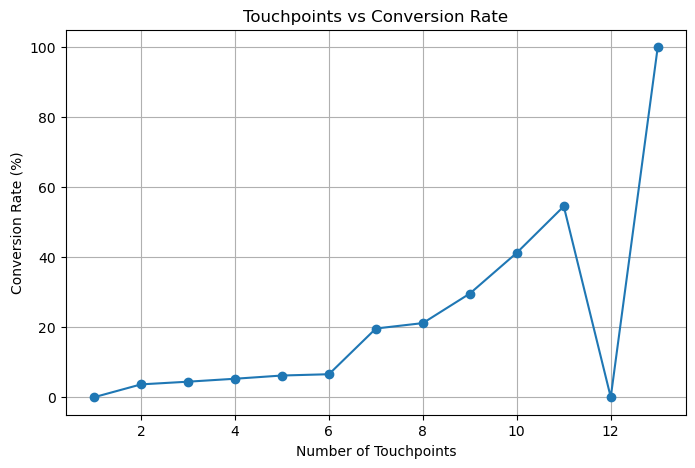

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    nonlinear_summary.index,
    nonlinear_summary["Conversion_Rate_%"],
    marker="o"
)

plt.xlabel("Number of Touchpoints")
plt.ylabel("Conversion Rate (%)")
plt.title("Touchpoints vs Conversion Rate")

plt.grid(True)

plt.show()

In [92]:
nonlinear_summary["Conversion_Change"] = (
    nonlinear_summary["Conversion_Rate_%"]
    .diff()
)

nonlinear_summary

,Users,Purchasers,Conversion_Rate_%,Conversion_Change
Touchpoints,,,,
1,14759,0,0.00,NaN
2,15086,553,3.67,3.67
3,15175,674,4.44,0.77
4,15404,814,5.28,0.84
5,15123,937,6.20,0.92
6,15043,989,6.57,0.37
7,5400,1060,19.63,13.06
8,1582,335,21.18,1.55
9,341,101,29.62,8.44


In [93]:
# ==========================================================
# NON-LINEAR CONVERSION PATH - INTERPRETATION
# ==========================================================

# The relationship between touchpoints and conversion rate was
# found to be non-linear.

# Conversion increased gradually from 3.67% at 2 touchpoints
# to 6.57% at 6 touchpoints. However, a sharp increase was
# observed at 7 touchpoints, where conversion rose to 19.63%.

# Beyond 7 touchpoints, conversion continued to increase,
# reaching 41.27% at 10 touchpoints.

# This demonstrates that conversion does not grow in a directly
# proportional manner with customer exposure. Instead, customers
# appear to require a critical level of engagement before the
# probability of purchase increases substantially.

# Results for touchpoints 11-13 were excluded from interpretation
# because they contained very few users (11, 1, and 1 users
# respectively), making them statistically unreliable.

# Therefore, the dataset exhibits a clear non-linear conversion
# path, confirming that simple linear attribution assumptions
# would provide misleading business insights.

# PHASE 0-- BUILDING CUSTOMER JOURNEYS( REMOVING CONSECUTIVE DUPLICATE CHANNELS )

In [95]:
# ==========================================================
# REMOVE BOT DETECTION COLUMNS
# ==========================================================

touchpoints_clean = touchpoints_clean.drop(
    columns=[
        "prev_ts",
        "gap_sec",
        "Previous_Channel"
    ],
    errors="ignore"
)

touchpoints_clean.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,Month,Bot_Flag
0,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression,2026-01,False
1,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression,2026-01,False
2,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click,2026-01,False
3,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression,2026-01,False
4,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression,2026-01,False


In [96]:
# ==========================================================
# SORT CUSTOMER JOURNEYS
# ==========================================================

touchpoints_clean = (
    touchpoints_clean
    .sort_values(
        ["User_ID", "Timestamp"]
    )
    .reset_index(drop=True)
)

touchpoints_clean.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,Month,Bot_Flag
0,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression,2026-01,False
1,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression,2026-01,False
2,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click,2026-01,False
3,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression,2026-01,False
4,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression,2026-01,False


In [97]:
# ==========================================================
# REMOVE CONSECUTIVE DUPLICATE CHANNELS
# ==========================================================

touchpoints_clean["Previous_Channel"] = (

    touchpoints_clean
    .groupby("User_ID")["Channel"]
    .shift(1)

)

journey_data = (

    touchpoints_clean[

        (
            touchpoints_clean["Channel"]
            !=
            touchpoints_clean["Previous_Channel"]
        )

        |

        (
            touchpoints_clean["Previous_Channel"]
            .isna()
        )

    ]

    .copy()

)

# Remove helper column from journey dataset
journey_data.drop(
    columns=["Previous_Channel"],
    inplace=True
)

In [98]:
# ==========================================================
# VERIFY DUPLICATE REMOVAL
# ==========================================================

remaining_duplicates = (

    journey_data["Channel"]

    ==

    journey_data
    .groupby("User_ID")["Channel"]
    .shift(1)

).sum()

print("Original Rows :", len(touchpoints_clean))
print("Rows After Removing Consecutive Duplicates :", len(journey_data))
print("Rows Removed :", len(touchpoints_clean) - len(journey_data))
print()
print("Remaining Consecutive Duplicates :", remaining_duplicates)

Original Rows : 372246
Rows After Removing Consecutive Duplicates : 295429
Rows Removed : 76817

Remaining Consecutive Duplicates : 0


In [99]:
# ==========================================================
# FINAL CLEANUP
# ==========================================================

touchpoints_clean.drop(
    columns=["Previous_Channel"],
    inplace=True,
    errors="ignore"
)

touchpoints_clean.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,Month,Bot_Flag
0,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression,2026-01,False
1,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression,2026-01,False
2,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click,2026-01,False
3,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression,2026-01,False
4,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression,2026-01,False


In [100]:
# Consecutive duplicate channel interactions were removed from the
# cleaned dataset to simplify customer journeys. A total of 76,817
# repeated channel visits (20.6% of all touchpoints) were eliminated,
# reducing the dataset from 372,246 to 295,429 touchpoints.
#
# Verification confirmed that no consecutive duplicate channels remain,
# ensuring that the subsequent Markov attribution model captures only
# meaningful transitions between marketing channels.

# PHASE 1- ATTRIBUTION FRAMEWORK FOR EACH BRAND

# REUSABLE FUNCTION USED FOR EACH BRAND

In [103]:
    # ==========================================================
    # REUSABLE MARKOV ATTRIBUTION FUNCTION
    # ==========================================================
    
    def run_markov(brand_id):
    
        print("="*80)
        print(f"MARKOV ATTRIBUTION ANALYSIS : {brand_id}")
        print("="*80)
    
        # ------------------------------------------------------
        # STEP 1 : FILTER BRAND DATA
        # ------------------------------------------------------
    
        users = touchpoints_clean[
            touchpoints_clean["User_ID"].str.startswith(f"U_{brand_id}")
        ]["User_ID"].unique()
    
        brand_journey = journey_data[
            journey_data["User_ID"].isin(users)
        ].copy()
    
        purchase_users = set(
    
            touchpoints_clean[
                (touchpoints_clean["User_ID"].isin(users)) &
                (touchpoints_clean["Event_Type"]=="Purchase")
            ]["User_ID"]
    
        )
    
        print("Brand Users       :", len(users))
        print("Purchasing Users  :", len(purchase_users))
        print("Journey Rows      :", len(brand_journey))
        print()
            # ------------------------------------------------------
        # STEP 2 : CREATE MARKOV INPUT
        # ------------------------------------------------------
    
        # Create one journey string per customer
        paths = (
            brand_journey
            .groupby("User_ID")["Channel"]
            .apply(lambda x: ">".join(x))
        )
    
        # Build input required by ChannelAttribution package
        markov_input = pd.DataFrame({
            "User_ID": paths.index,
            "Path": paths.values
        })
    
        # Identify converting customers
        markov_input["Conversion"] = (
            markov_input["User_ID"]
            .isin(purchase_users)
            .astype(int)
        )
    
        # Identify non-converting customers
        markov_input["Null"] = 1 - markov_input["Conversion"]
    
        print("Customer Journeys :", len(markov_input))
    
        print("\nSample Markov Input\n")
        display(markov_input.head())
        # ------------------------------------------------------
        # STEP 3 : BUILD READABLE TRANSITION MATRIX
        # ------------------------------------------------------
    
        transitions = []
    
        for journey in markov_input["Path"]:
    
            states = ["START"] + journey.split(">")
    
            for i in range(len(states) - 1):
    
                transitions.append(
                    [states[i], states[i + 1]]
                )
    
        transition_df = pd.DataFrame(
            transitions,
            columns=["From", "To"]
        )
    
        # Transition Counts
        transition_counts = pd.crosstab(
            transition_df["From"],
            transition_df["To"]
        )
    
        # Convert Counts to Transition Probabilities
        readable_transition_matrix = (
            transition_counts
            .div(
                transition_counts.sum(axis=1),
                axis=0
            )
            .round(3)
        )
    
        print("\nTransition Probability Matrix\n")
    
        display(readable_transition_matrix)
        # ------------------------------------------------------
        # STEP 4 : RUN MARKOV ATTRIBUTION MODEL
        # ------------------------------------------------------
    
        model = ca.markov_model(
    
            Data=markov_input,
    
            var_path="Path",
    
            var_conv="Conversion",
    
            var_null="Null",
    
            sep=">",
    
            out_more=True,
    
            verbose=False
    
        )
    
        # Extract package outputs
        attribution = model["result"].copy()
    
        removal_effects = model["removal_effects"].copy()
    
        # ------------------------------------------------------
        # STEP 5 : CALCULATE ATTRIBUTION PERCENTAGE
        # ------------------------------------------------------
    
        attribution["Attribution (%)"] = (
    
            attribution["total_conversions"]
    
            /
    
            attribution["total_conversions"].sum()
    
            * 100
    
        )
        # ------------------------------------------------------
        # STEP 6 : DISPLAY MARKOV RESULTS
        # ------------------------------------------------------

        print("\nRemoval Effects\n")

        display(

            removal_effects

            .sort_values(
                by="removal_effect",
                ascending=False
            )

            .reset_index(drop=True)

         )

        print("\nChannel Attribution\n")

        attribution = attribution.sort_values(
            by="Attribution (%)",
            ascending=False
        ).reset_index(drop=True)

        display(attribution)

        # ------------------------------------------------------
        # STEP 7 : TOP & BOTTOM FUNNEL ANALYSIS
        # ------------------------------------------------------

        # Consider only successful customer journeys

        converted_paths = markov_input[
            markov_input["Conversion"] == 1
        ]["Path"]

        funnel_records = []

        for journey in converted_paths:

            channels = journey.split(">")

            # First touchpoint
            funnel_records.append(
                [channels[0], "First"]
            )

            # Last touchpoint
            if len(channels) > 1:

                funnel_records.append(
                    [channels[-1], "Last"]
                )

        funnel_df = pd.DataFrame(
            funnel_records,
            columns=["Channel", "Position"]
        )

        funnel_summary = pd.crosstab(
            funnel_df["Channel"],
            funnel_df["Position"]
        )

        # Ensure both columns exist

        for col in ["First", "Last"]:

            if col not in funnel_summary.columns:

                funnel_summary[col] = 0

        funnel_summary = funnel_summary[
            ["First", "Last"]
        ]

        # Convert to percentages

        funnel_percentage = (

            funnel_summary

            .div(
                funnel_summary.sum(axis=1),
                 axis=0
            )

            * 100

        ).round(2)

        # Classify channel role

        funnel_percentage["Primary Role"] = np.where(

            funnel_percentage["First"] >= funnel_percentage["Last"],

            "Top Funnel Primer",

            "Bottom Funnel Converter"

        )

        # Rename columns for clarity

        funnel_percentage = funnel_percentage.rename(
            columns={
                "First": "First Touch (%)",
                "Last": "Last Touch (%)"
            }
        )

        # Sort output

        funnel_percentage = funnel_percentage.sort_values(
            by=[
                "Primary Role",
                "First Touch (%)",
                "Last Touch (%)"
            ],
            ascending=[True, False, False]
        )

        print("\nTop & Bottom Funnel Channels\n")

        display(funnel_percentage)
    
        
        
    
        # ------------------------------------------------------
        # STEP 8 : RETURN ALL RESULTS
        # ------------------------------------------------------
    
        return {
    
            "brand": brand_id,
    
            "users": users,
    
            "purchase_users": purchase_users,
    
            "journey_data": brand_journey,
    
            "markov_input": markov_input,
    
            "transition_matrix": readable_transition_matrix,
    
            "removal_effects": removal_effects,
    
            "attribution": attribution,
    
            "funnel_roles": funnel_percentage
    
        }
# ==========================================================
# MARKOV ATTRIBUTION MODEL - INTERPRETATION
# ==========================================================

# STEP 1 : FILTER BRAND DATA

# Customer journeys were separated brand-wise so that each brand
# could be analysed independently. Users belonging to the selected
# brand were identified, and their complete marketing journeys
# together with purchase behaviour were extracted. This ensured
# that attribution was calculated only from interactions relevant
# to the selected brand.

# ----------------------------------------------------------

# STEP 2 : CREATE MARKOV MODEL INPUT

# Individual customer journeys were converted into sequential
# channel paths required by the Markov attribution model.
# Each customer was labelled as either a converting user
# (Conversion = 1) or a non-converting user (Null = 1),
# enabling the algorithm to learn which channel sequences
# were most likely to result in a purchase.

# ----------------------------------------------------------

# STEP 3 : BUILD TRANSITION PROBABILITY MATRIX

# A transition probability matrix was generated to represent
# the likelihood of customers moving from one marketing
# channel to another throughout their journey.
# Unlike the internal matrix produced by the library, a
# readable transition matrix using actual channel names
# was constructed to improve interpretability and enable
# easier visualization of customer movement between channels.

# ----------------------------------------------------------

# STEP 4 : RUN MARKOV ATTRIBUTION MODEL

# The Channel Attribution package was used to estimate a
# first-order Markov model for each brand. The model evaluates
# every possible customer transition and measures the impact
# of removing each marketing channel from the journey,
# allowing conversion credit to be assigned according to
# each channel's actual contribution rather than relying on
# heuristic attribution methods.

# ----------------------------------------------------------

# STEP 5 : CALCULATE ATTRIBUTION PERCENTAGE

# The total conversions assigned to each marketing channel
# by the Markov model were converted into percentage
# contributions. This provides an intuitive comparison of
# the relative influence of every channel on overall
# conversions for the selected brand.

# ----------------------------------------------------------

# STEP 6 : DISPLAY MARKOV RESULTS

# Two important outputs were generated:
#
# 1. Removal Effect
#    Quantifies the reduction in total conversions if a
#    particular channel were removed from the customer journey.
#    Higher removal effects indicate greater strategic
#    importance within the conversion path.
#
# 2. Channel Attribution
#    Displays the estimated conversions and percentage
#    contribution assigned to each marketing channel by the
#    Markov model.

# ----------------------------------------------------------

# STEP 7 : TOP & BOTTOM FUNNEL ANALYSIS

# Only successful customer journeys were analysed to determine
# the functional role of each marketing channel.
#
# • The first channel in each converted journey was treated
#   as the Top-of-Funnel touchpoint responsible for customer
#   acquisition.
#
# • The last channel before purchase was treated as the
#   Bottom-of-Funnel touchpoint responsible for conversion.
#
# The proportion of first-touch and last-touch appearances
# was calculated for every channel. Channels appearing more
# frequently as the first interaction were classified as
# Top Funnel Primers, whereas channels appearing more often
# immediately before purchase were classified as Bottom
# Funnel Converters.

# ----------------------------------------------------------

# STEP 8 : STORE RESULTS

# All outputs including customer journeys, transition matrix,
# Markov attribution, removal effects, and funnel roles were
# stored in a reusable dictionary. This allowed identical
# analysis to be performed automatically for all ten brands
# without rewriting the code and provided a consistent input
# for the subsequent budget optimization phase.

# BRAND 1

In [105]:
b01 = run_markov("B01")

MARKOV ATTRIBUTION ANALYSIS : B01
Brand Users       : 9792
Purchasing Users  : 697
Journey Rows      : 29599

Customer Journeys : 9792

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B01_00000,Influencer Blog,0,1
1,U_B01_00001,Google Search>Marketplace>Instagram>Influencer...,0,1
2,U_B01_00002,Marketplace>Google Search>YouTube>Influencer B...,0,1
3,U_B01_00003,Google Search>Instagram,0,1
4,U_B01_00004,Google Search>YouTube,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.247,0.265,0.232,0.256
Influencer Blog,0.255,0.000,0.258,0.257,0.230
Instagram,0.236,0.250,0.000,0.251,0.262
Marketplace,0.242,0.242,0.271,0.000,0.245
START,0.203,0.195,0.206,0.201,0.195
YouTube,0.245,0.243,0.262,0.251,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Instagram,0.781065
1,Influencer Blog,0.381657
2,Marketplace,0.378698
3,YouTube,0.372781
4,Google Search,0.356509



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Instagram,239.749837,34.397394
1,Influencer Blog,117.150489,16.807818
2,Marketplace,116.242345,16.677524
3,YouTube,114.426059,16.416938
4,Google Search,109.431270,15.700326



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
Instagram,33.69,66.31,Bottom Funnel Converter
Marketplace,74.84,25.16,Top Funnel Primer
YouTube,73.46,26.54,Top Funnel Primer
Influencer Blog,73.12,26.88,Top Funnel Primer
Google Search,70.95,29.05,Top Funnel Primer


# BRAND 2

In [107]:
b02 = run_markov("B02")

MARKOV ATTRIBUTION ANALYSIS : B02
Brand Users       : 9804
Purchasing Users  : 1277
Journey Rows      : 30209

Customer Journeys : 9804

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B02_00000,Instagram>YouTube>Google Search,0,1
1,U_B02_00001,YouTube>Google Search>Instagram>Influencer Blo...,0,1
2,U_B02_00002,Influencer Blog>YouTube>Marketplace>Google Search,1,0
3,U_B02_00003,Influencer Blog>Google Search>YouTube>Marketpl...,0,1
4,U_B02_00004,YouTube>Marketplace>Google Search>Marketplace>...,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.261,0.242,0.252,0.245
Influencer Blog,0.310,0.000,0.226,0.241,0.223
Instagram,0.270,0.247,0.000,0.255,0.228
Marketplace,0.286,0.230,0.244,0.000,0.240
START,0.197,0.204,0.200,0.199,0.199
YouTube,0.286,0.240,0.238,0.236,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Google Search,0.902478
1,Marketplace,0.358913
2,Influencer Blog,0.352518
3,YouTube,0.343725
4,Instagram,0.338929



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Google Search,501.821441,39.296902
1,Marketplace,199.572920,15.628263
2,Influencer Blog,196.017055,15.349809
3,YouTube,191.127741,14.966934
4,Instagram,188.460842,14.758093



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
Google Search,26.41,73.59,Bottom Funnel Converter
Influencer Blog,94.32,5.68,Top Funnel Primer
Instagram,84.14,15.86,Top Funnel Primer
YouTube,83.26,16.74,Top Funnel Primer
Marketplace,82.63,17.37,Top Funnel Primer


# BRAND 3

In [109]:
b03 = run_markov("B03")

MARKOV ATTRIBUTION ANALYSIS : B03
Brand Users       : 9816
Purchasing Users  : 303
Journey Rows      : 29678

Customer Journeys : 9816

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B03_00000,Instagram>Influencer Blog>YouTube>Marketplace>...,0,1
1,U_B03_00001,Marketplace>YouTube,0,1
2,U_B03_00002,Marketplace>Google Search>Influencer Blog>Inst...,0,1
3,U_B03_00003,Marketplace>YouTube>Influencer Blog>YouTube,0,1
4,U_B03_00004,Google Search>Marketplace>YouTube>Marketplace,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.238,0.252,0.255,0.256
Influencer Blog,0.260,0.000,0.254,0.241,0.245
Instagram,0.256,0.250,0.000,0.243,0.252
Marketplace,0.246,0.254,0.233,0.000,0.266
START,0.198,0.200,0.197,0.203,0.202
YouTube,0.255,0.240,0.254,0.251,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Influencer Blog,0.472069
1,Google Search,0.451613
2,YouTube,0.437713
3,Instagram,0.413323
4,Marketplace,0.410176



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Influencer Blog,65.466331,21.606050
1,Google Search,62.629456,20.669788
2,YouTube,60.701837,20.033609
3,Instagram,57.319409,18.917297
4,Marketplace,56.882967,18.773257



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
YouTube,61.82,38.18,Top Funnel Primer
Marketplace,58.70,41.30,Top Funnel Primer
Google Search,54.31,45.69,Top Funnel Primer
Influencer Blog,53.78,46.22,Top Funnel Primer
Instagram,52.43,47.57,Top Funnel Primer


# BRAND 4

In [111]:
b04 = run_markov("B04")

MARKOV ATTRIBUTION ANALYSIS : B04
Brand Users       : 9811
Purchasing Users  : 315
Journey Rows      : 29393

Customer Journeys : 9811

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B04_00000,Marketplace>Influencer Blog>YouTube,0,1
1,U_B04_00001,Instagram>Google Search>Instagram>YouTube,0,1
2,U_B04_00002,Instagram>Marketplace>YouTube,0,1
3,U_B04_00003,Marketplace>Instagram>Google Search>YouTube,0,1
4,U_B04_00004,YouTube>Influencer Blog,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.250,0.249,0.248,0.252
Influencer Blog,0.257,0.000,0.259,0.239,0.246
Instagram,0.242,0.252,0.000,0.249,0.257
Marketplace,0.253,0.255,0.244,0.000,0.248
START,0.198,0.199,0.206,0.199,0.198
YouTube,0.244,0.251,0.253,0.252,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Influencer Blog,0.474734
1,Google Search,0.428856
2,Instagram,0.416888
3,Marketplace,0.410904
4,YouTube,0.406915



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Influencer Blog,69.934701,22.201493
1,Google Search,63.176306,20.055970
2,Instagram,61.413246,19.496269
3,Marketplace,60.531716,19.216418
4,YouTube,59.944030,19.029851



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
Influencer Blog,44.72,55.28,Bottom Funnel Converter
YouTube,64.17,35.83,Top Funnel Primer
Marketplace,60.66,39.34,Top Funnel Primer
Instagram,57.29,42.71,Top Funnel Primer
Google Search,51.43,48.57,Top Funnel Primer


# BRAND 5

In [113]:
b05 = run_markov("B05")

MARKOV ATTRIBUTION ANALYSIS : B05
Brand Users       : 9781
Purchasing Users  : 161
Journey Rows      : 29083

Customer Journeys : 9781

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B05_00000,Instagram>YouTube>Google Search,0,1
1,U_B05_00001,Instagram>Influencer Blog>Instagram>YouTube,0,1
2,U_B05_00002,Influencer Blog>Instagram>Influencer Blog,0,1
3,U_B05_00003,Influencer Blog>Instagram>YouTube,0,1
4,U_B05_00004,Google Search>Marketplace,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.247,0.246,0.254,0.253
Influencer Blog,0.256,0.000,0.245,0.257,0.242
Instagram,0.258,0.243,0.000,0.252,0.248
Marketplace,0.261,0.240,0.252,0.000,0.247
START,0.199,0.208,0.196,0.199,0.198
YouTube,0.259,0.249,0.240,0.252,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Marketplace,0.516056
1,Google Search,0.486022
2,Influencer Blog,0.485266
3,Instagram,0.461277
4,YouTube,0.315451



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Marketplace,36.697147,22.793259
1,Google Search,34.561405,21.466711
2,Influencer Blog,34.507676,21.433339
3,Instagram,32.801769,20.373769
4,YouTube,22.432004,13.932922



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
YouTube,20.00,80.00,Bottom Funnel Converter
Influencer Blog,67.21,32.79,Top Funnel Primer
Google Search,65.15,34.85,Top Funnel Primer
Marketplace,60.00,40.00,Top Funnel Primer
Instagram,58.62,41.38,Top Funnel Primer


# BRAND 6

In [115]:
b06 = run_markov("B06")

MARKOV ATTRIBUTION ANALYSIS : B06
Brand Users       : 9790
Purchasing Users  : 290
Journey Rows      : 29519

Customer Journeys : 9790

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B06_00000,Influencer Blog>YouTube>Instagram,0,1
1,U_B06_00001,YouTube>Google Search>Instagram,0,1
2,U_B06_00002,YouTube>Google Search>Instagram,0,1
3,U_B06_00003,YouTube>Google Search>Instagram>Marketplace>Yo...,0,1
4,U_B06_00004,Google Search>Marketplace>YouTube,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.254,0.254,0.242,0.250
Influencer Blog,0.252,0.000,0.256,0.241,0.250
Instagram,0.242,0.254,0.000,0.254,0.250
Marketplace,0.243,0.265,0.253,0.000,0.239
START,0.200,0.190,0.203,0.201,0.206
YouTube,0.252,0.249,0.246,0.253,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Google Search,0.470493
1,YouTube,0.461601
2,Marketplace,0.455133
3,Influencer Blog,0.454325
4,Instagram,0.433306



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Google Search,59.978678,20.682303
1,YouTube,58.845060,20.291400
2,Marketplace,58.020611,20.007107
3,Influencer Blog,57.917555,19.971571
4,Instagram,55.238095,19.047619



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
Google Search,48.18,51.82,Bottom Funnel Converter
Instagram,59.78,40.22,Top Funnel Primer
Marketplace,59.32,40.68,Top Funnel Primer
Influencer Blog,57.73,42.27,Top Funnel Primer
YouTube,53.85,46.15,Top Funnel Primer


# BRAND 7

In [117]:
b07 = run_markov("B07")

MARKOV ATTRIBUTION ANALYSIS : B07
Brand Users       : 9796
Purchasing Users  : 1633
Journey Rows      : 29995

Customer Journeys : 9796

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B07_00000,Instagram,0,1
1,U_B07_00001,Marketplace>Influencer Blog>YouTube>Marketplace,0,1
2,U_B07_00002,Influencer Blog,0,1
3,U_B07_00003,Instagram>YouTube>Influencer Blog,0,1
4,U_B07_00004,YouTube>Instagram>Marketplace>YouTube,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.241,0.253,0.259,0.246
Influencer Blog,0.296,0.000,0.223,0.243,0.237
Instagram,0.288,0.239,0.000,0.238,0.235
Marketplace,0.256,0.242,0.262,0.000,0.240
START,0.201,0.206,0.201,0.192,0.200
YouTube,0.286,0.229,0.238,0.247,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Google Search,0.794937
1,Marketplace,0.459494
2,Influencer Blog,0.351266
3,YouTube,0.346203
4,Instagram,0.344937



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Google Search,565.182695,34.610085
1,Marketplace,326.689997,20.005511
2,Influencer Blog,249.742353,15.293469
3,YouTube,246.142463,15.073023
4,Instagram,245.242491,15.017911



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
Marketplace,40.38,59.62,Bottom Funnel Converter
Google Search,37.26,62.74,Bottom Funnel Converter
Influencer Blog,93.63,6.37,Top Funnel Primer
YouTube,91.48,8.52,Top Funnel Primer
Instagram,90.11,9.89,Top Funnel Primer


# BRAND 8

In [119]:
b08 = run_markov("B08")

MARKOV ATTRIBUTION ANALYSIS : B08
Brand Users       : 9801
Purchasing Users  : 305
Journey Rows      : 29117

Customer Journeys : 9801

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B08_00000,Instagram>Influencer Blog>Google Search>Market...,0,1
1,U_B08_00001,Marketplace>Google Search>Marketplace,0,1
2,U_B08_00002,Google Search>Influencer Blog>Instagram,0,1
3,U_B08_00003,Google Search>Marketplace>YouTube,0,1
4,U_B08_00004,YouTube>Influencer Blog>YouTube>Google Search,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.250,0.244,0.255,0.252
Influencer Blog,0.257,0.000,0.246,0.251,0.245
Instagram,0.249,0.250,0.000,0.234,0.267
Marketplace,0.241,0.249,0.252,0.000,0.258
START,0.198,0.194,0.203,0.202,0.203
YouTube,0.257,0.241,0.256,0.246,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Marketplace,0.473473
1,Google Search,0.473027
2,YouTube,0.457423
3,Instagram,0.421757
4,Influencer Blog,0.411057



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Marketplace,64.562488,21.168029
1,Google Search,64.501694,21.148096
2,YouTube,62.373929,20.450468
3,Instagram,57.510464,18.855890
4,Influencer Blog,56.051425,18.377516



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
Influencer Blog,62.26,37.74,Top Funnel Primer
Instagram,60.61,39.39,Top Funnel Primer
YouTube,56.57,43.43,Top Funnel Primer
Google Search,53.51,46.49,Top Funnel Primer
Marketplace,51.67,48.33,Top Funnel Primer


# BRAND 9

In [121]:
b09 = run_markov("B09")

MARKOV ATTRIBUTION ANALYSIS : B09
Brand Users       : 9796
Purchasing Users  : 208
Journey Rows      : 29645

Customer Journeys : 9796

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B09_00000,Google Search>YouTube,0,1
1,U_B09_00001,Google Search>YouTube>Marketplace,0,1
2,U_B09_00002,Google Search>Marketplace>YouTube>Marketplace,0,1
3,U_B09_00003,YouTube>Instagram>Influencer Blog>Google Search,0,1
4,U_B09_00004,YouTube>Influencer Blog>Instagram,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.246,0.263,0.248,0.244
Influencer Blog,0.253,0.000,0.245,0.253,0.249
Instagram,0.249,0.246,0.000,0.254,0.251
Marketplace,0.252,0.266,0.241,0.000,0.241
START,0.200,0.200,0.202,0.197,0.201
YouTube,0.251,0.247,0.244,0.258,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Marketplace,0.876153
1,Google Search,0.368346
2,Instagram,0.361604
3,YouTube,0.358410
4,Influencer Blog,0.336764



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Marketplace,79.190748,38.072475
1,Google Search,33.292830,16.006168
2,Instagram,32.683423,15.713184
3,YouTube,32.394757,15.574402
4,Influencer Blog,30.438242,14.633770



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
Marketplace,29.73,70.27,Bottom Funnel Converter
Influencer Blog,90.48,9.52,Top Funnel Primer
YouTube,82.69,17.31,Top Funnel Primer
Instagram,79.41,20.59,Top Funnel Primer
Google Search,79.07,20.93,Top Funnel Primer


# BRAND 10

In [123]:
b10 = run_markov("B10")

MARKOV ATTRIBUTION ANALYSIS : B10
Brand Users       : 9802
Purchasing Users  : 307
Journey Rows      : 29191

Customer Journeys : 9802

Sample Markov Input



,User_ID,Path,Conversion,Null
0,U_B10_00000,Instagram>Google Search>YouTube>Marketplace>Yo...,0,1
1,U_B10_00001,Influencer Blog>YouTube>Instagram,0,1
2,U_B10_00002,Influencer Blog,0,1
3,U_B10_00004,Marketplace>Influencer Blog>Google Search>Infl...,0,1
4,U_B10_00005,Google Search>Marketplace>YouTube>Influencer Blog,0,1



Transition Probability Matrix



To,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,
Google Search,0.000,0.253,0.245,0.258,0.243
Influencer Blog,0.241,0.000,0.258,0.250,0.251
Instagram,0.254,0.243,0.000,0.251,0.252
Marketplace,0.253,0.249,0.245,0.000,0.253
START,0.198,0.195,0.201,0.201,0.205
YouTube,0.251,0.244,0.247,0.258,0.000


*** Install ChannelAttribution Pro for free running install_pro(). Visit https://channelattribution.io for more info. Set flg_pro=False to hide this message.

Removal Effects



,channel_name,removal_effect
0,Influencer Blog,0.446112
1,Marketplace,0.444748
2,Google Search,0.422920
3,YouTube,0.420191
4,Instagram,0.413370



Channel Attribution



,channel_name,total_conversions,Attribution (%)
0,Influencer Blog,63.779543,20.775095
1,Marketplace,63.584498,20.711563
2,Google Search,60.463787,19.695044
3,YouTube,60.073698,19.567980
4,Instagram,59.098475,19.250318



Top & Bottom Funnel Channels



Position,First Touch (%),Last Touch (%),Primary Role
Channel,,,
YouTube,58.59,41.41,Top Funnel Primer
Google Search,56.73,43.27,Top Funnel Primer
Influencer Blog,56.14,43.86,Top Funnel Primer
Instagram,55.88,44.12,Top Funnel Primer
Marketplace,55.20,44.80,Top Funnel Primer


In [124]:
# ==========================================================
# STORE ALL BRAND RESULTS
# ==========================================================

all_brands = {

    "B01": b01,
    "B02": b02,
    "B03": b03,
    "B04": b04,
    "B05": b05,
    "B06": b06,
    "B07": b07,
    "B08": b08,
    "B09": b09,
    "B10": b10

}

In [125]:
# ==========================================================
# TOP ATTRIBUTION CHANNEL OF EACH BRAND
# ==========================================================

brand_summary = []

for brand, result in all_brands.items():

    top_channel = (

        result["attribution"]

        .sort_values(
            "Attribution (%)",
            ascending=False
        )

        .iloc[0]

    )

    brand_summary.append({

        "Brand": brand,

        "Top Channel": top_channel["channel_name"],

        "Attribution (%)": round(
            top_channel["Attribution (%)"],
            2
        )

    })

brand_summary = pd.DataFrame(brand_summary)

display(brand_summary)

,Brand,Top Channel,Attribution (%)
0,B01,Instagram,34.40
1,B02,Google Search,39.30
2,B03,Influencer Blog,21.61
3,B04,Influencer Blog,22.20
4,B05,Marketplace,22.79
5,B06,Google Search,20.68
6,B07,Google Search,34.61
7,B08,Marketplace,21.17
8,B09,Marketplace,38.07
9,B10,Influencer Blog,20.78


In [126]:
# ==========================================================
# TOP & BOTTOM FUNNEL CHANNELS
# ==========================================================

funnel_summary = []

for brand, result in all_brands.items():

    roles = result["funnel_roles"]

    top = roles[
        roles["Primary Role"]=="Top Funnel Primer"
    ].index.tolist()

    bottom = roles[
        roles["Primary Role"]=="Bottom Funnel Converter"
    ].index.tolist()

    funnel_summary.append({

        "Brand": brand,

        "Top Funnel": ", ".join(top),

        "Bottom Funnel": ", ".join(bottom)

    })

funnel_summary = pd.DataFrame(funnel_summary)

display(funnel_summary)

,Brand,Top Funnel,Bottom Funnel
0,B01,"Marketplace, YouTube, Influencer Blog, Google ...",Instagram
1,B02,"Influencer Blog, Instagram, YouTube, Marketplace",Google Search
2,B03,"YouTube, Marketplace, Google Search, Influence...",
3,B04,"YouTube, Marketplace, Instagram, Google Search",Influencer Blog
4,B05,"Influencer Blog, Google Search, Marketplace, I...",YouTube
5,B06,"Instagram, Marketplace, Influencer Blog, YouTube",Google Search
6,B07,"Influencer Blog, YouTube, Instagram","Marketplace, Google Search"
7,B08,"Influencer Blog, Instagram, YouTube, Google Se...",
8,B09,"Influencer Blog, YouTube, Instagram, Google Se...",Marketplace
9,B10,"YouTube, Google Search, Influencer Blog, Insta...",


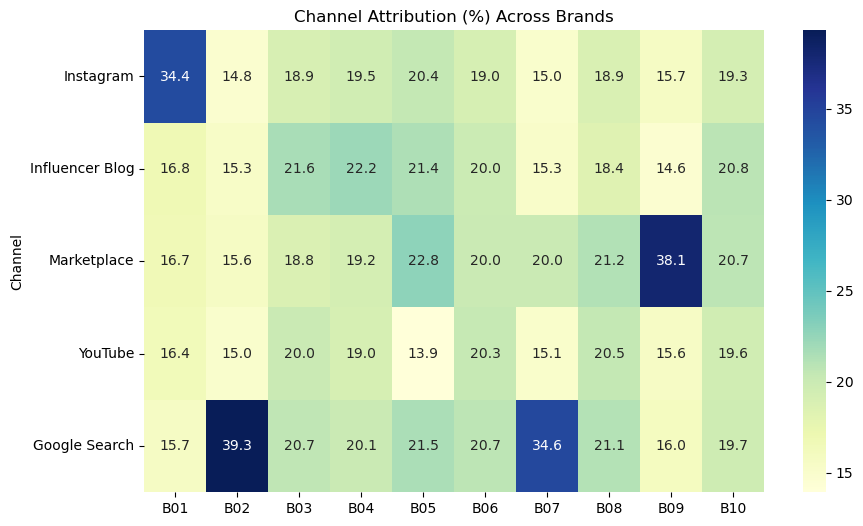

In [127]:
heatmap_df = pd.DataFrame()

for brand, result in all_brands.items():

    temp = result["attribution"][

        ["channel_name","Attribution (%)"]

    ]

    temp.columns = [

        "Channel",

        brand

    ]

    temp = temp.set_index("Channel")

    heatmap_df = pd.concat(

        [heatmap_df,temp],

        axis=1

    )

plt.figure(figsize=(10,6))

sns.heatmap(

    heatmap_df,

    annot=True,

    cmap="YlGnBu",

    fmt=".1f"

)

plt.title("Channel Attribution (%) Across Brands")

plt.show()
# ==========================================================
# MARKOV ATTRIBUTION ACROSS BRANDS - INTERPRETATION
# ==========================================================

# The heatmap presents the percentage contribution of each
# marketing channel to conversions for all 10 brands using
# the Markov Attribution model.

# Unlike the Last-Click model, Markov attribution distributes
# conversion credit across all influential touchpoints in the
# customer journey, providing a more balanced estimate of
# channel performance.

# Most brands exhibit a relatively balanced attribution
# distribution (approximately 15%–22%) across channels,
# indicating that multiple marketing channels collectively
# influence customer conversions rather than a single channel.

# However, a few brands show clear channel dominance:
# - Brand B01: Instagram contributed the highest attribution
#   (34.4%), making it the primary conversion driver.
# - Brand B02: Google Search accounted for 39.3% of total
#   attributed conversions.
# - Brand B07: Google Search remained dominant with 34.6%
#   attribution.
# - Brand B09: Marketplace contributed the highest share
#   (38.1%) of conversions.

# These results demonstrate that the optimal marketing channel
# differs across brands, highlighting the need for brand-
# specific budget allocation instead of applying a uniform
# investment strategy across all channels.

In [128]:
# ==========================================================
# PHASE 1 FINAL SUMMARY TABLE
# ==========================================================

phase1_summary = []

for brand, result in all_brands.items():

    # -----------------------------
    # Top Attribution Channel
    # -----------------------------

    top_attr = (

        result["attribution"]

        .sort_values(
            "Attribution (%)",
            ascending=False
        )

        .iloc[0]

    )

    # -----------------------------
    # Highest Removal Effect
    # -----------------------------

    top_removal = (

        result["removal_effects"]

        .sort_values(
            "removal_effect",
            ascending=False
        )

        .iloc[0]

    )

    # -----------------------------
    # Top Funnel Primer
    # -----------------------------

    top_funnel = (

        result["funnel_roles"]

        [

            result["funnel_roles"]["Primary Role"]

            ==

            "Top Funnel Primer"

        ]

        .index

        .tolist()

    )

    # -----------------------------
    # Bottom Funnel Converter
    # -----------------------------

    bottom_funnel = (

        result["funnel_roles"]

        [

            result["funnel_roles"]["Primary Role"]

            ==

            "Bottom Funnel Converter"

        ]

        .index

        .tolist()

    )

    phase1_summary.append({

        "Brand": brand,

        "Top Attribution Channel":
            top_attr["channel_name"],

        "Attribution (%)":
            round(
                top_attr["Attribution (%)"],
                2
            ),

        "Highest Removal Effect":
            top_removal["channel_name"],

        "Removal Effect":
            round(
                top_removal["removal_effect"],
                3
            ),

        "Top Funnel Primer":
            ", ".join(top_funnel),

        "Bottom Funnel Converter":
            ", ".join(bottom_funnel)

    })

phase1_summary = pd.DataFrame(phase1_summary)

display(phase1_summary)

,Brand,Top Attribution Channel,Attribution (%),Highest Removal Effect,Removal Effect,Top Funnel Primer,Bottom Funnel Converter
0,B01,Instagram,34.40,Instagram,0.781,"Marketplace, YouTube, Influencer Blog, Google ...",Instagram
1,B02,Google Search,39.30,Google Search,0.902,"Influencer Blog, Instagram, YouTube, Marketplace",Google Search
2,B03,Influencer Blog,21.61,Influencer Blog,0.472,"YouTube, Marketplace, Google Search, Influence...",
3,B04,Influencer Blog,22.20,Influencer Blog,0.475,"YouTube, Marketplace, Instagram, Google Search",Influencer Blog
4,B05,Marketplace,22.79,Marketplace,0.516,"Influencer Blog, Google Search, Marketplace, I...",YouTube
5,B06,Google Search,20.68,Google Search,0.470,"Instagram, Marketplace, Influencer Blog, YouTube",Google Search
6,B07,Google Search,34.61,Google Search,0.795,"Influencer Blog, YouTube, Instagram","Marketplace, Google Search"
7,B08,Marketplace,21.17,Marketplace,0.473,"Influencer Blog, Instagram, YouTube, Google Se...",
8,B09,Marketplace,38.07,Marketplace,0.876,"Influencer Blog, YouTube, Instagram, Google Se...",Marketplace
9,B10,Influencer Blog,20.78,Influencer Blog,0.446,"YouTube, Google Search, Influencer Blog, Insta...",


# PHASE 2 PORTFOLIO ALLOCATION

In [130]:
true_cpa = []

for brand, result in all_brands.items():

    attribution = result["attribution"].copy()

    spend = campaigns[
        campaigns["Brand_ID"] == brand
    ][["Channel", "Total_Budget_Allocated"]]

    temp = attribution.merge(
        spend,
        left_on="channel_name",
        right_on="Channel"
    )

    temp["True CPA"] = (
        temp["Total_Budget_Allocated"] /
        temp["total_conversions"]
    ).round(2)

    temp["Brand"] = brand

    true_cpa.append(temp)

true_cpa = pd.concat(true_cpa, ignore_index=True)

display(true_cpa)

,channel_name,total_conversions,Attribution (%),Channel,Total_Budget_Allocated,True CPA,Brand
0,Instagram,239.749837,34.397394,Instagram,613144.27,2557.43,B01
1,Influencer Blog,117.150489,16.807818,Influencer Blog,14499430.43,123767.56,B01
2,Marketplace,116.242345,16.677524,Marketplace,37182759.79,319872.76,B01
3,YouTube,114.426059,16.416938,YouTube,19807806.26,173105.73,B01
4,Google Search,109.431270,15.700326,Google Search,27896859.25,254925.85,B01
5,Google Search,501.821441,39.296902,Google Search,23670390.50,47168.95,B02
6,Marketplace,199.572920,15.628263,Marketplace,31212839.26,156398.17,B02
7,Influencer Blog,196.017055,15.349809,Influencer Blog,1570849.00,8013.84,B02
8,YouTube,191.127741,14.966934,YouTube,22462493.63,117526.08,B02
9,Instagram,188.460842,14.758093,Instagram,21083427.60,111871.66,B02


In [131]:
true_cpa = true_cpa.sort_values(
    ["Brand", "Attribution (%)"],
    ascending=[True, False]
).reset_index(drop=True)

display(true_cpa)

,channel_name,total_conversions,Attribution (%),Channel,Total_Budget_Allocated,True CPA,Brand
0,Instagram,239.749837,34.397394,Instagram,613144.27,2557.43,B01
1,Influencer Blog,117.150489,16.807818,Influencer Blog,14499430.43,123767.56,B01
2,Marketplace,116.242345,16.677524,Marketplace,37182759.79,319872.76,B01
3,YouTube,114.426059,16.416938,YouTube,19807806.26,173105.73,B01
4,Google Search,109.431270,15.700326,Google Search,27896859.25,254925.85,B01
5,Google Search,501.821441,39.296902,Google Search,23670390.50,47168.95,B02
6,Marketplace,199.572920,15.628263,Marketplace,31212839.26,156398.17,B02
7,Influencer Blog,196.017055,15.349809,Influencer Blog,1570849.00,8013.84,B02
8,YouTube,191.127741,14.966934,YouTube,22462493.63,117526.08,B02
9,Instagram,188.460842,14.758093,Instagram,21083427.60,111871.66,B02


In [132]:
# ==========================================================
# PHASE 2 - STEP 2 : CALCULATE NORMALIZED OPTIMIZATION SCORE
# ==========================================================

optimization = []

for brand, result in all_brands.items():

    # ------------------------------------------------------
    # Attribution
    # ------------------------------------------------------

    attr = result["attribution"].copy()

    # ------------------------------------------------------
    # Removal Effect
    # ------------------------------------------------------

    removal = result["removal_effects"].copy()

    # ------------------------------------------------------
    # True CPA
    # ------------------------------------------------------

    cpa = true_cpa[
        true_cpa["Brand"] == brand
    ][["channel_name", "True CPA"]]

    # ------------------------------------------------------
    # Merge all metrics
    # ------------------------------------------------------

    temp = attr.merge(
        removal,
        on="channel_name"
    )

    temp = temp.merge(
        cpa,
        on="channel_name"
    )

    # ------------------------------------------------------
    # Normalize Attribution
    # ------------------------------------------------------

    temp["Attr Score"] = (

        temp["Attribution (%)"]

        /

        temp["Attribution (%)"].max()

    )

    # ------------------------------------------------------
    # Normalize Removal Effect
    # ------------------------------------------------------

    temp["Removal Score"] = (

        temp["removal_effect"]

        /

        temp["removal_effect"].max()

    )

    # ------------------------------------------------------
    # Normalize CPA
    # Lower CPA = Better
    # ------------------------------------------------------

    temp["CPA Score"] = (

        temp["True CPA"].min()

        /

        temp["True CPA"]

    )

    # ------------------------------------------------------
    # Final Optimization Score
    # ------------------------------------------------------

    temp["Optimization Score"] = (

        0.50 * temp["Attr Score"]

        +

        0.30 * temp["Removal Score"]

        +

        0.20 * temp["CPA Score"]

    )

    temp["Brand"] = brand

    optimization.append(temp)

# ==========================================================
# Combine all brands
# ==========================================================

optimization = pd.concat(
    optimization,
    ignore_index=True
)

optimization = optimization.sort_values(

    ["Brand", "Optimization Score"],

    ascending=[True, False]

).reset_index(drop=True)

print("Optimization Scores")

display(

    optimization[[
        "Brand",
        "channel_name",
        "Attribution (%)",
        "removal_effect",
        "True CPA",
        "Attr Score",
        "Removal Score",
        "CPA Score",
        "Optimization Score"
    ]]

)
# ==========================================================
# WEIGHTED MULTI-CRITERIA DECISION MODEL - INTERPRETATION
# ==========================================================

# To determine the optimal budget allocation for each brand,
# a Weighted Multi-Criteria Decision Model (WMCDM) was developed.
# This approach evaluates every marketing channel using multiple
# business performance indicators instead of relying on a single metric.

# Three criteria were considered:
#
# 1. Markov Attribution (%)
#    - Measures each channel's contribution across the complete
#      customer journey.
#
# 2. Removal Effect
#    - Measures the importance of a channel by estimating the
#      reduction in conversions if that channel is removed.
#
# 3. Markov True CPA
#    - Measures the cost required to generate one conversion
#      after fairly distributing conversion credit using
#      Markov attribution.
#
# Since these metrics have different units and scales,
# each criterion was normalized to values between 0 and 1
# to enable fair comparison.

# A weighted scoring approach was then applied:
#
# Optimization Score =
# 0.50 × Attribution Score
# + 0.30 × Removal Effect Score
# + 0.20 × CPA Score
#
# where:
# - 50% weight prioritizes channels driving conversions,
# - 30% weight captures channel dependency within the customer journey,
# - 20% weight rewards cost-efficient channels.

# Channels with higher Optimization Scores provide the best
# balance between conversion contribution, strategic importance,
# and acquisition cost. These scores form the basis for the
# optimized ₹10 Crore budget allocation for each brand.

Optimization Scores


,Brand,channel_name,Attribution (%),removal_effect,True CPA,Attr Score,Removal Score,CPA Score,Optimization Score
0,B01,Instagram,34.397394,0.781065,2557.43,1.000000,1.000000,1.000000,1.000000
1,B01,Influencer Blog,16.807818,0.381657,123767.56,0.488636,0.488636,0.020663,0.395042
2,B01,Marketplace,16.677524,0.378698,319872.76,0.484848,0.484848,0.007995,0.389478
3,B01,YouTube,16.416938,0.372781,173105.73,0.477273,0.477273,0.014774,0.384773
4,B01,Google Search,15.700326,0.356509,254925.85,0.456439,0.456439,0.010032,0.367158
5,B02,Google Search,39.296902,0.902478,47168.95,1.000000,1.000000,0.169897,0.833979
6,B02,Influencer Blog,15.349809,0.352518,8013.84,0.390611,0.390611,1.000000,0.512489
7,B02,Marketplace,15.628263,0.358913,156398.17,0.397697,0.397697,0.051240,0.328406
8,B02,YouTube,14.966934,0.343725,117526.08,0.380868,0.380868,0.068188,0.318332
9,B02,Instagram,14.758093,0.338929,111871.66,0.375554,0.375554,0.071634,0.314770


In [133]:
# ==========================================================
# PHASE 2 - STEP 3 : ALLOCATE ₹10 CRORE PER BRAND
# ==========================================================

budget_allocation = optimization.copy()

# Total budget available for each brand
BRAND_BUDGET = 10_00_00_000      # ₹10 Crore

# Normalize Optimization Score within each brand
budget_allocation["Score Sum"] = (

    budget_allocation

    .groupby("Brand")["Optimization Score"]

    .transform("sum")

)

budget_allocation["Budget Allocation (INR)"] = (

    budget_allocation["Optimization Score"]

    /

    budget_allocation["Score Sum"]

) * BRAND_BUDGET

budget_allocation["Budget Allocation (Crore)"] = (

    budget_allocation["Budget Allocation (INR)"]

    / 10000000

).round(2)

budget_allocation = budget_allocation.sort_values(

    ["Brand","Budget Allocation (Crore)"],

    ascending=[True,False]

).reset_index(drop=True)

print("Optimized Budget Allocation")

display(

    budget_allocation[

        [

            "Brand",

            "channel_name",

            "Attribution (%)",

            "removal_effect",

            "True CPA",

            "Optimization Score",

            "Budget Allocation (Crore)"

        ]

    ]

)

Optimized Budget Allocation


,Brand,channel_name,Attribution (%),removal_effect,True CPA,Optimization Score,Budget Allocation (Crore)
0,B01,Instagram,34.397394,0.781065,2557.43,1.000000,3.94
1,B01,Influencer Blog,16.807818,0.381657,123767.56,0.395042,1.56
2,B01,Marketplace,16.677524,0.378698,319872.76,0.389478,1.54
3,B01,YouTube,16.416938,0.372781,173105.73,0.384773,1.52
4,B01,Google Search,15.700326,0.356509,254925.85,0.367158,1.45
5,B02,Google Search,39.296902,0.902478,47168.95,0.833979,3.61
6,B02,Influencer Blog,15.349809,0.352518,8013.84,0.512489,2.22
7,B02,Marketplace,15.628263,0.358913,156398.17,0.328406,1.42
8,B02,YouTube,14.966934,0.343725,117526.08,0.318332,1.38
9,B02,Instagram,14.758093,0.338929,111871.66,0.314770,1.36


In [134]:
# ==========================================================
# VERIFY BUDGET CONSTRAINT
# ==========================================================

budget_check = (

    budget_allocation

    .groupby("Brand")["Budget Allocation (Crore)"]

    .sum()

    .round(2)

    .reset_index()

)

budget_check.columns = [

    "Brand",

    "Total Budget (Crore)"

]

display(budget_check)

,Brand,Total Budget (Crore)
0,B01,10.01
1,B02,9.99
2,B03,10.01
3,B04,10.00
4,B05,10.00
5,B06,10.00
6,B07,10.00
7,B08,10.00
8,B09,10.01
9,B10,10.01


In [135]:
# LAST TOUCH TABULATION
historical = []

for brand in all_brands.keys():

    # Campaign spend
    spend = (
        campaigns[
            campaigns["Brand_ID"] == brand
        ]
        .groupby("Channel")["Total_Budget_Allocated"]
        .sum()
        .reset_index()
    )

    # Purchase events only
    conv = (
        touchpoints_clean[
            touchpoints_clean["Event_Type"] == "Purchase"
        ]
        .merge(
            campaigns[
                ["Campaign_ID","Brand_ID"]
            ],
            on="Campaign_ID"
        )
    )

    conv = (
        conv[
            conv["Brand_ID"] == brand
        ]
        .groupby("Channel")
        .size()
        .reset_index(
            name="Historical_Conversions"
        )
    )

    total_conv = conv["Historical_Conversions"].sum()

    conv["Historical Attribution (%)"] = (
        conv["Historical_Conversions"]
        / total_conv
        *100
    ).round(2)

    hist = conv.merge(
        spend,
        on="Channel"
    )

    hist["Historical CPA"] = (
        hist["Total_Budget_Allocated"]
        /
        hist["Historical_Conversions"]
    ).round(2)

    hist["Historical Budget (Crore)"] = (
        hist["Total_Budget_Allocated"]
        /
        10000000
    ).round(2)

    hist.rename(
        columns={
            "Channel":"channel_name"
        },
        inplace=True
    )

    hist["Brand"] = brand

    historical.append(
        hist[
            [
                "Brand",
                "channel_name",
                "Historical Budget (Crore)",
                "Historical_Conversions",
                "Historical Attribution (%)",
                "Historical CPA"
            ]
        ]
    )

historical = pd.concat(
    historical,
    ignore_index=True
)

display(historical)

,Brand,channel_name,Historical Budget (Crore),Historical_Conversions,Historical Attribution (%),Historical CPA
0,B01,Google Search,2.79,56,8.03,498158.20
1,B01,Influencer Blog,1.45,63,9.04,230149.69
2,B01,Instagram,0.06,474,68.01,1293.55
3,B01,Marketplace,3.72,50,7.17,743655.20
4,B01,YouTube,1.98,54,7.75,366811.23
5,B02,Google Search,2.37,1098,85.98,21557.73
6,B02,Influencer Blog,0.16,36,2.82,43634.69
7,B02,Instagram,2.11,48,3.76,439238.08
8,B02,Marketplace,3.12,47,3.68,664102.96
9,B02,YouTube,2.25,48,3.76,467968.62


In [136]:
# ==========================================================
# FINAL COMPARISON TABLE
# ==========================================================

comparison = historical.merge(

    budget_allocation[
        [
            "Brand",
            "channel_name",
            "total_conversions",
            "Attribution (%)",
            "True CPA",
            "Budget Allocation (Crore)"
        ]
    ],

    on=["Brand","channel_name"],
    how="left"

)

comparison = comparison.rename(

    columns={

        "Historical Budget (Crore)" : "Historical Budget (Cr)",

        "Historical_Conversions" : "Last Click Conversions",

        "total_conversions" : "Markov Conversions",

        "Historical Attribution (%)" : "Last Click Attribution (%)",

        "Attribution (%)" : "Markov Attribution (%)",

        "Historical CPA" : "Original CPA",

        "True CPA" : "Markov True CPA",

        "Budget Allocation (Crore)" : "Optimized Budget (Cr)"

    }

)

comparison = comparison[

    [

        "Brand",

        "channel_name",

        "Historical Budget (Cr)",

        "Optimized Budget (Cr)",

        "Last Click Conversions",

        "Markov Conversions",

        "Last Click Attribution (%)",

        "Markov Attribution (%)",

        "Original CPA",

        "Markov True CPA"

    ]

]

comparison = comparison.sort_values(

    ["Brand","Markov Attribution (%)"],

    ascending=[True,False]

).reset_index(drop=True)

display(comparison)
# ==========================================================
# LAST-CLICK VS MARKOV ATTRIBUTION - INTERPRETATION
# ==========================================================

# The comparison demonstrates that the Last-Click attribution
# model assigns 100% of the conversion credit to the final
# interaction before purchase, ignoring the influence of
# previous marketing channels.

# In contrast, the Markov attribution model distributes
# conversion credit across all channels based on their actual
# contribution to the customer's journey.

# For example, in Brand B01, Instagram received 68.01% of the
# credit under the Last-Click model because it was frequently
# the final touchpoint before purchase. However, the Markov
# model reduced Instagram's contribution to 34.40% while
# redistributing the remaining credit to Influencer Blog
# (16.81%), Marketplace (16.68%), YouTube (16.42%), and
# Google Search (15.70%), reflecting their influence earlier
# in the customer journey.

# This demonstrates that Last-Click attribution tends to
# overestimate bottom-funnel channels, whereas the Markov
# model provides a more realistic representation of customer
# behaviour by recognizing the contribution of all marketing
# touchpoints involved in driving conversions.

,Brand,channel_name,Historical Budget (Cr),Optimized Budget (Cr),Last Click Conversions,Markov Conversions,Last Click Attribution (%),Markov Attribution (%),Original CPA,Markov True CPA
0,B01,Instagram,0.06,3.94,474,239.749837,68.01,34.397394,1293.55,2557.43
1,B01,Influencer Blog,1.45,1.56,63,117.150489,9.04,16.807818,230149.69,123767.56
2,B01,Marketplace,3.72,1.54,50,116.242345,7.17,16.677524,743655.20,319872.76
3,B01,YouTube,1.98,1.52,54,114.426059,7.75,16.416938,366811.23,173105.73
4,B01,Google Search,2.79,1.45,56,109.431270,8.03,15.700326,498158.20,254925.85
5,B02,Google Search,2.37,3.61,1098,501.821441,85.98,39.296902,21557.73,47168.95
6,B02,Marketplace,3.12,1.42,47,199.572920,3.68,15.628263,664102.96,156398.17
7,B02,Influencer Blog,0.16,2.22,36,196.017055,2.82,15.349809,43634.69,8013.84
8,B02,YouTube,2.25,1.38,48,191.127741,3.76,14.966934,467968.62,117526.08
9,B02,Instagram,2.11,1.36,48,188.460842,3.76,14.758093,439238.08,111871.66


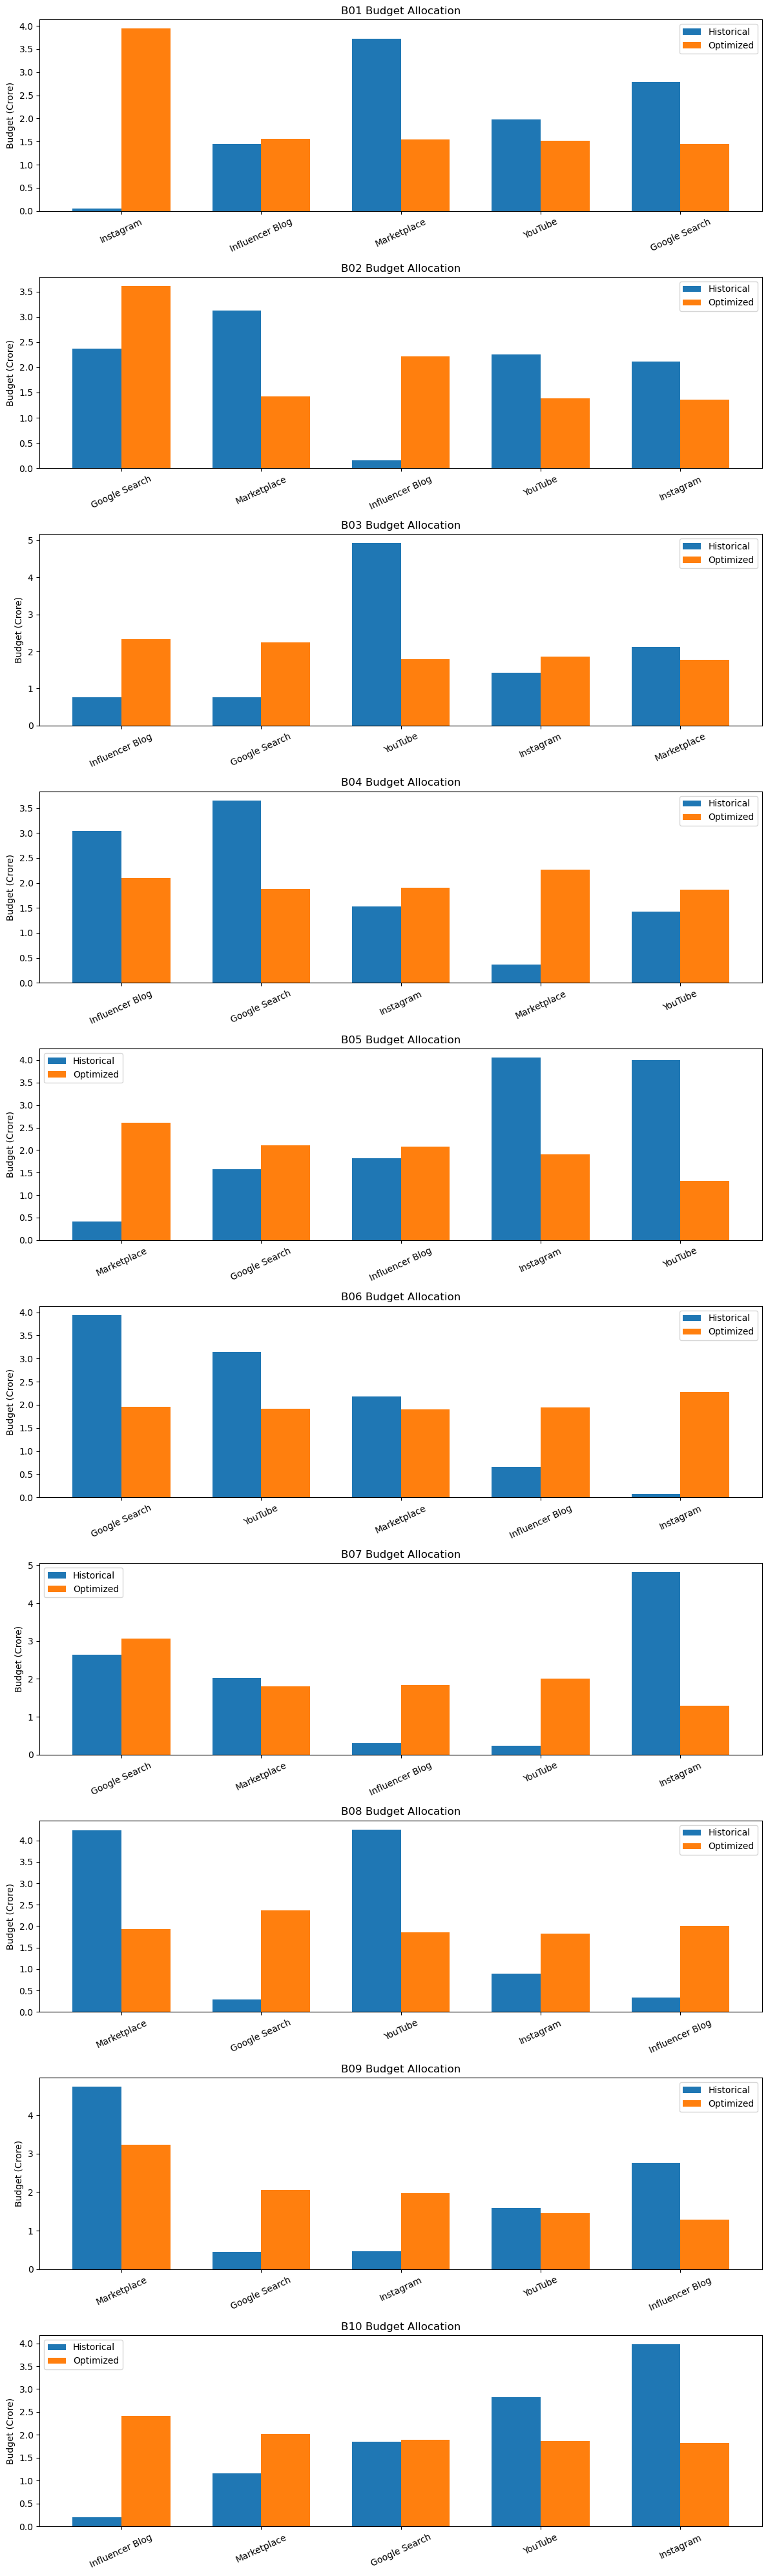

In [137]:
# ==========================================================
# HISTORICAL vs OPTIMIZED BUDGET
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

brands = comparison["Brand"].unique()

fig, axes = plt.subplots(
    len(brands),
    1,
    figsize=(12, 4*len(brands))
)

if len(brands)==1:
    axes=[axes]

for ax, brand in zip(axes, brands):

    df = comparison[
        comparison["Brand"]==brand
    ]

    x = np.arange(len(df))

    width = 0.35

    ax.bar(
        x-width/2,
        df["Historical Budget (Cr)"],
        width,
        label="Historical"
    )

    ax.bar(
        x+width/2,
        df["Optimized Budget (Cr)"],
        width,
        label="Optimized"
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        df["channel_name"],
        rotation=25
    )

    ax.set_ylabel("Budget (Crore)")

    ax.set_title(
        f"{brand} Budget Allocation"
    )

    ax.legend()

plt.tight_layout()

plt.show()

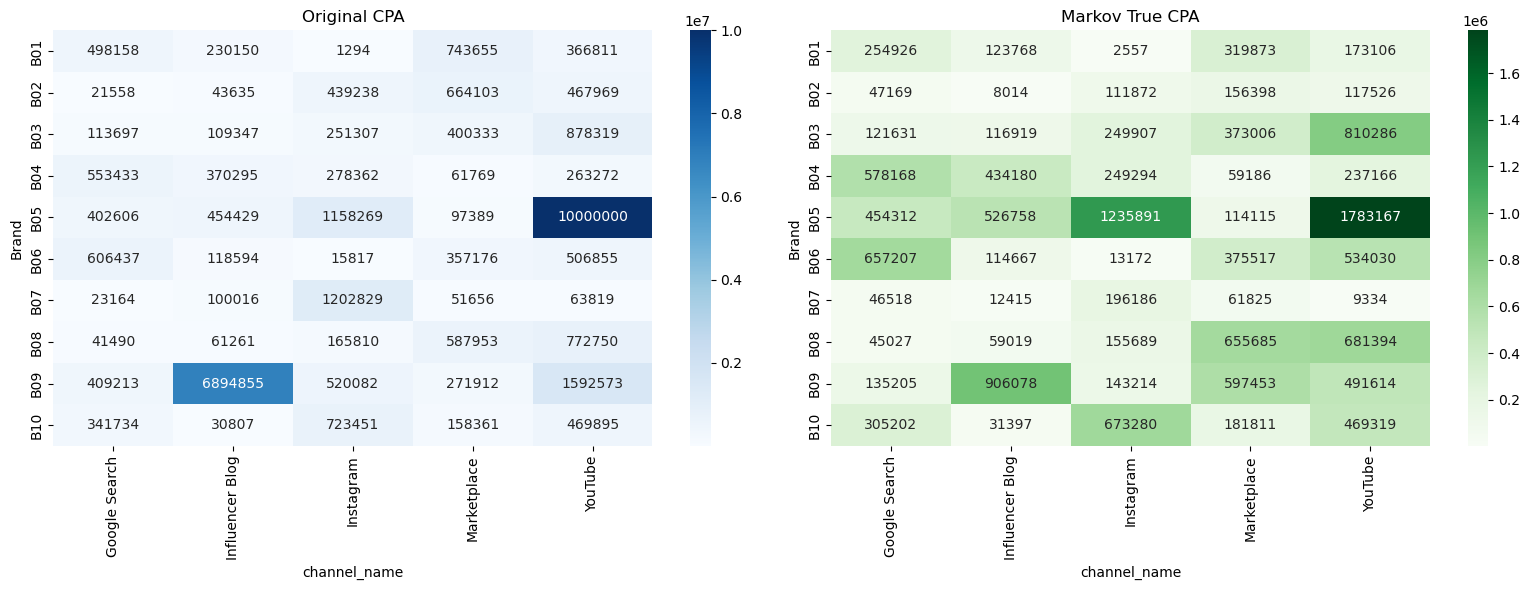

In [138]:
# ==========================================================
# ORIGINAL CPA vs TRUE CPA HEATMAP
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

heat = comparison.copy()

heat = heat.pivot_table(

    index="Brand",

    columns="channel_name",

    values="Original CPA"

)

heat2 = comparison.pivot_table(

    index="Brand",

    columns="channel_name",

    values="Markov True CPA"

)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

sns.heatmap(

    heat,

    annot=True,

    fmt=".0f",

    cmap="Blues",

    ax=axes[0]

)

axes[0].set_title(
    "Original CPA"
)

sns.heatmap(

    heat2,

    annot=True,

    fmt=".0f",

    cmap="Greens",

    ax=axes[1]

)

axes[1].set_title(
    "Markov True CPA"
)

plt.tight_layout()

plt.show()
# ==========================================================
# ORIGINAL CPA VS MARKOV TRUE CPA - INTERPRETATION
# ==========================================================

# The heatmaps compare the historical CPA calculated using the
# Last-Click attribution model with the True CPA calculated
# using Markov attribution for every brand-channel combination.

# Under the Last-Click model, the entire conversion credit is
# assigned to the final touchpoint, which often underestimates
# the true acquisition cost of bottom-funnel channels while
# overestimating the CPA of assisting channels.

# The Markov model redistributes conversion credit across all
# influential touchpoints, resulting in a more realistic True CPA
# that reflects each channel's actual contribution throughout
# the customer journey.

# For example, in Brand B01:
# - Instagram's Original CPA = ₹1,294
# - Markov True CPA = ₹2,557
# This indicates that Instagram received excessive credit under
# the Last-Click model, whereas Markov recognized the influence
# of other channels before conversion.

# Another example is Brand B05:
# - YouTube Original CPA = ₹10,000,000
# - Markov True CPA = ₹1,783,167
# After redistributing conversion credit, YouTube's effective
# acquisition cost reduced substantially, demonstrating that
# it contributed to many customer journeys despite rarely being
# the final touchpoint.

# Overall, the Markov-based True CPA provides a more reliable
# metric for budget allocation by accounting for the complete
# customer journey rather than only the last interaction.

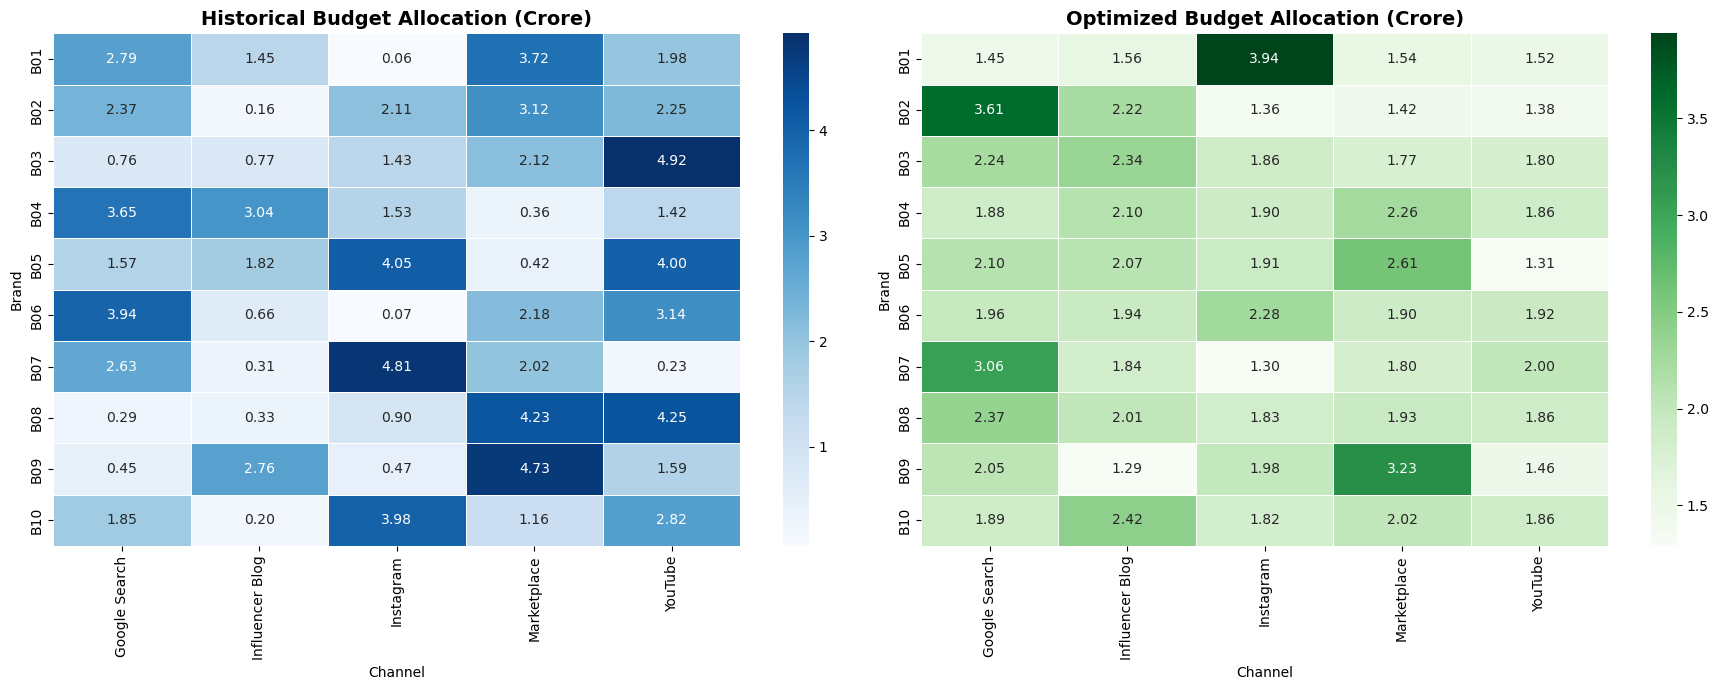

In [139]:
# ==========================================================
# BUDGET COMPARISON HEATMAP
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Historical Budget
historical_budget = comparison.pivot_table(
    index="Brand",
    columns="channel_name",
    values="Historical Budget (Cr)"
)

# Optimized Budget
optimized_budget = comparison.pivot_table(
    index="Brand",
    columns="channel_name",
    values="Optimized Budget (Cr)"
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Historical
sns.heatmap(
    historical_budget,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title(
    "Historical Budget Allocation (Crore)",
    fontsize=14,
    weight="bold"
)

axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Brand")

# Optimized
sns.heatmap(
    optimized_budget,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5,
    ax=axes[1]
)

axes[1].set_title(
    "Optimized Budget Allocation (Crore)",
    fontsize=14,
    weight="bold"
)

axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Brand")

plt.tight_layout()

plt.show()
# ==========================================================
# HISTORICAL VS OPTIMIZED BUDGET ALLOCATION - INTERPRETATION
# ==========================================================

# The heatmaps compare the historical marketing budget allocation
# with the optimized budget allocation obtained using the Markov
# attribution model and True CPA.

# Historically, budgets were concentrated on a few channels based
# on Last-Click performance, resulting in highly uneven spending
# across marketing channels.

# The optimization framework redistributed the fixed ₹10 Crore
# budget for each brand towards channels that generated higher
# incremental contribution at lower True CPA, while reducing
# over-investment in inefficient channels.

# For example, Brand B01 historically allocated only ₹0.06 Cr
# to Instagram, whereas the optimized allocation increased it
# to ₹3.94 Cr because Markov attribution identified Instagram
# as the most influential channel in the customer journey.

# Similarly, Brand B03 reduced YouTube's allocation from
# ₹4.92 Cr to ₹1.80 Cr while increasing investment in Google
# Search and Influencer Blog, resulting in a more balanced
# distribution of marketing spend.

# Overall, the optimized allocation shifts investment from
# historically biased spending patterns toward data-driven
# budget allocation based on each channel's true contribution
# to conversions.

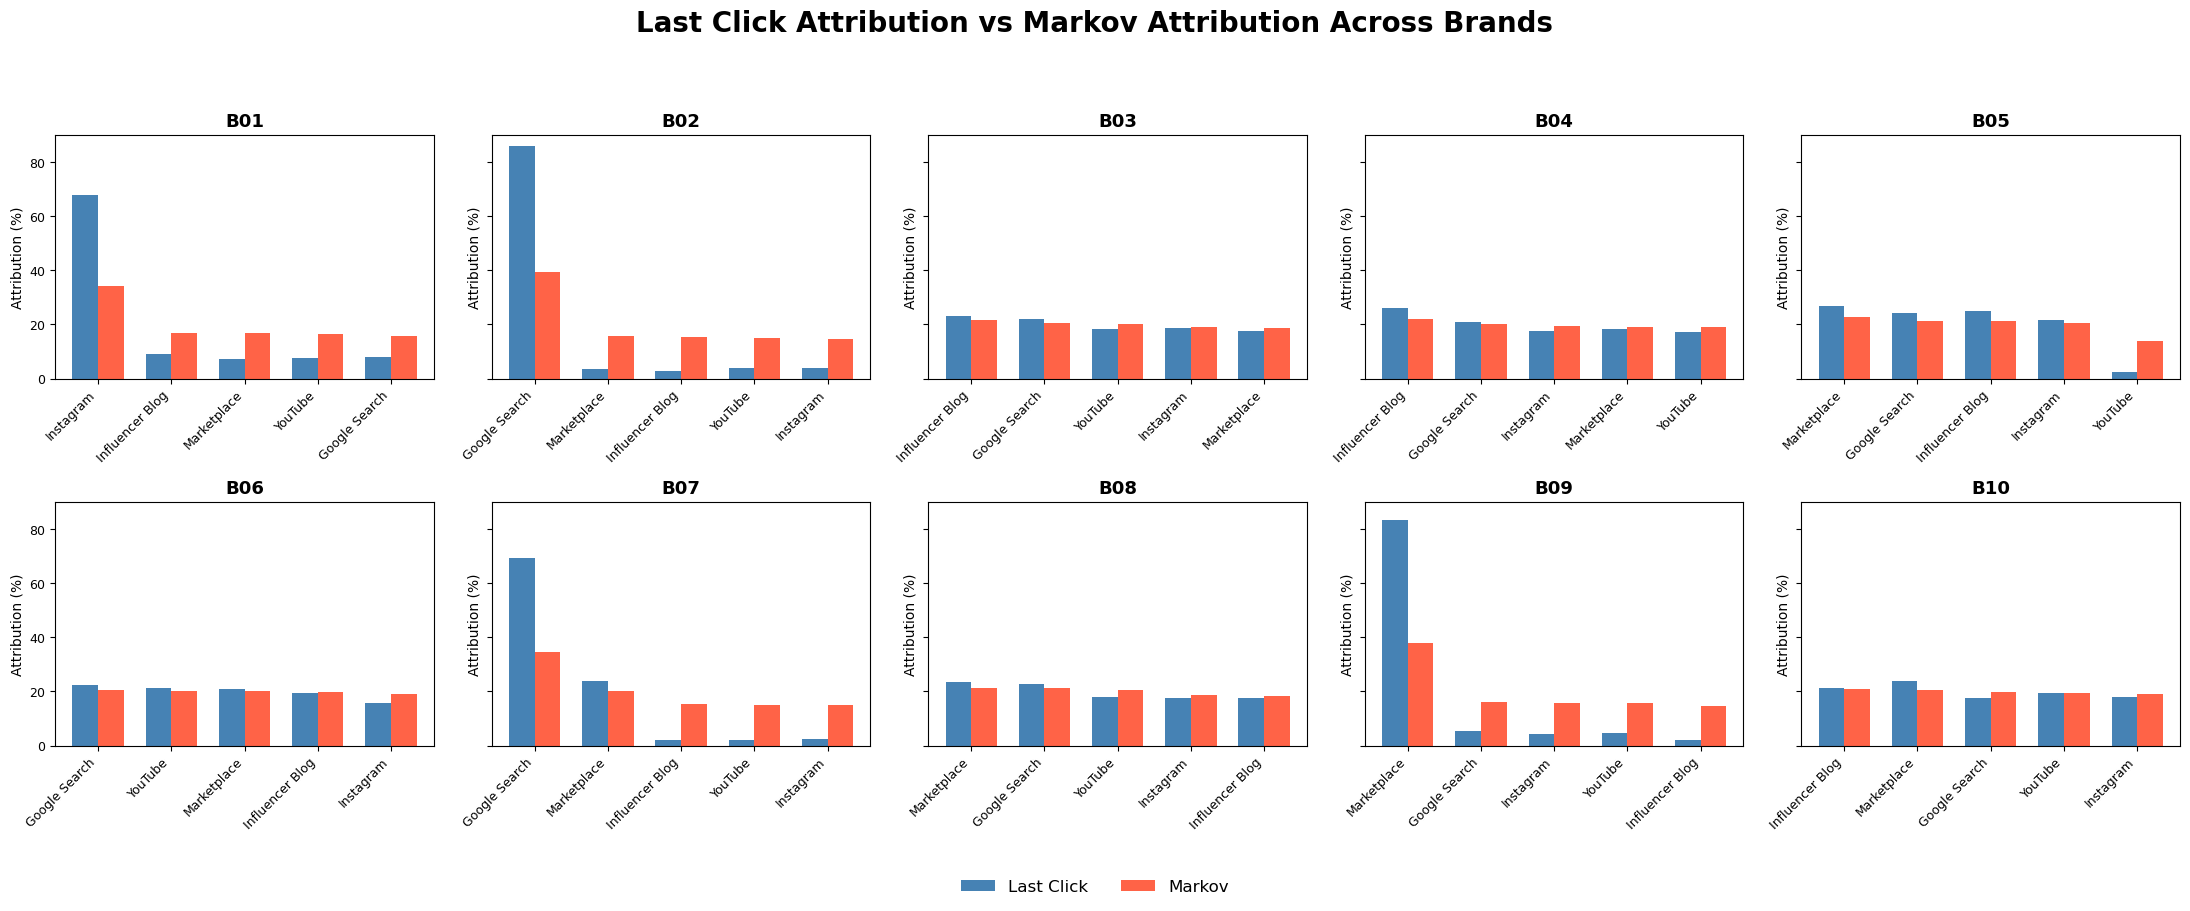

In [140]:
# ==========================================================
# LAST CLICK VS MARKOV ATTRIBUTION COMPARISON
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

brands = comparison["Brand"].unique()

fig, axes = plt.subplots(
    2,
    5,
    figsize=(22, 9),
    sharey=True
)

axes = axes.flatten()

for i, brand in enumerate(brands):

    df = comparison[
        comparison["Brand"] == brand
    ].copy()

    x = np.arange(len(df))
    width = 0.35

    # Last Click Attribution
    axes[i].bar(
        x - width/2,
        df["Last Click Attribution (%)"],
        width,
        color="steelblue",
        label="Last Click"
    )

    # Markov Attribution
    axes[i].bar(
        x + width/2,
        df["Markov Attribution (%)"],
        width,
        color="tomato",
        label="Markov"
    )

    axes[i].set_title(
        brand,
        fontsize=13,
        fontweight="bold"
    )

    axes[i].set_xticks(x)

    axes[i].set_xticklabels(
        df["channel_name"],
        rotation=45,
        ha="right",
        fontsize=9
    )

    axes[i].set_ylabel(
        "Attribution (%)",
        fontsize=10
    )

    axes[i].tick_params(axis="y", labelsize=9)

# ---------------------------------------------------------
# Common Legend (Bottom)
# ---------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=12,
    frameon=False
)

# ---------------------------------------------------------
# Main Title
# ---------------------------------------------------------

fig.suptitle(
    "Last Click Attribution vs Markov Attribution Across Brands",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

plt.tight_layout(
    rect=[0, 0.05, 1, 0.93]
)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

plt.savefig(
    "last_click_vs_markov_attribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

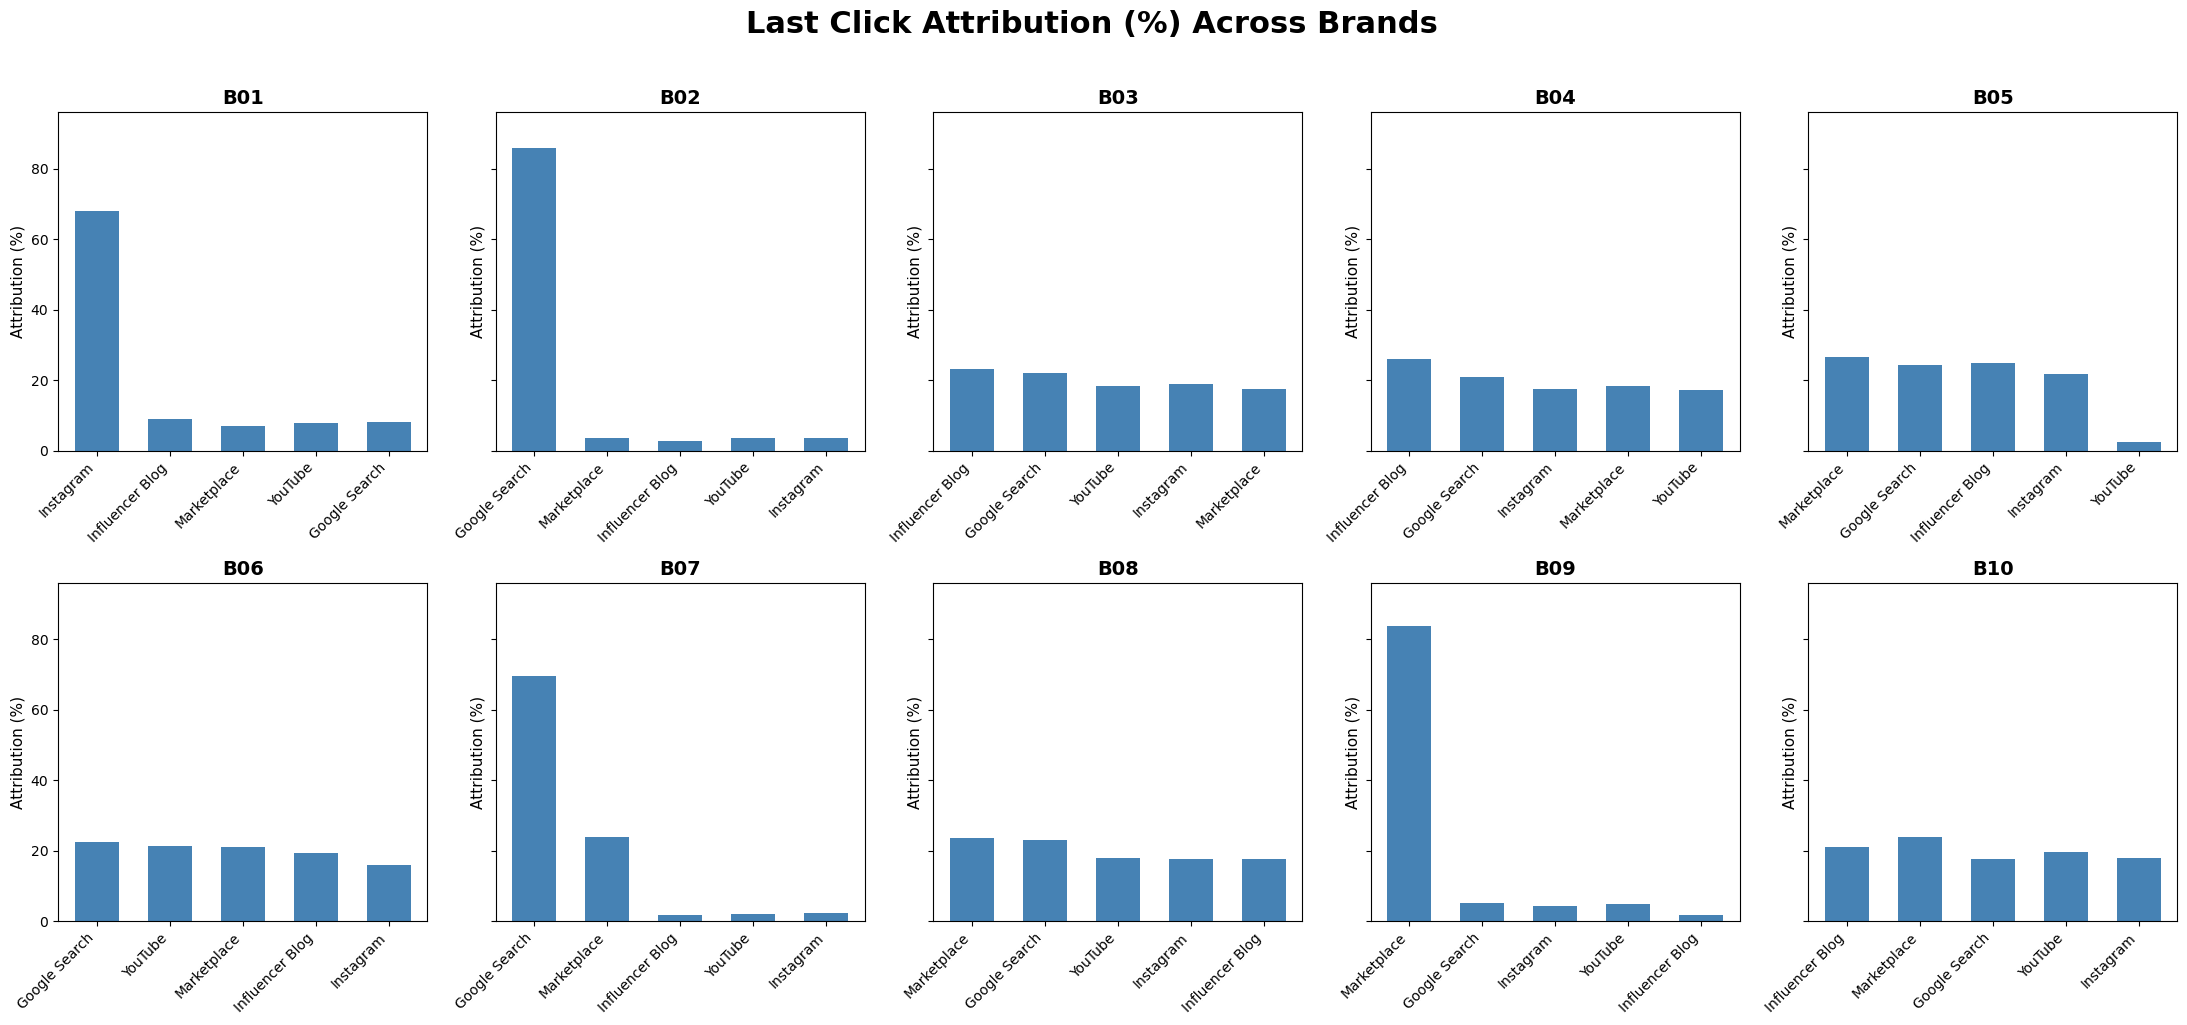

In [141]:
# ==========================================================
# LAST CLICK ATTRIBUTION (%) ACROSS BRANDS
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

brands = comparison["Brand"].unique()

fig, axes = plt.subplots(
    2,
    5,
    figsize=(22, 10),     # Bigger figure
    sharey=True
)

axes = axes.flatten()

for i, brand in enumerate(brands):

    df = comparison[
        comparison["Brand"] == brand
    ].copy()

    x = np.arange(len(df))

    axes[i].bar(
        x,
        df["Last Click Attribution (%)"],
        color="steelblue",
        width=0.60
    )

    axes[i].set_title(
        brand,
        fontsize=14,
        fontweight="bold"
    )

    axes[i].set_xticks(x)

    axes[i].set_xticklabels(
        df["channel_name"],
        rotation=45,
        ha="right",
        fontsize=10
    )

    axes[i].set_ylabel(
        "Attribution (%)",
        fontsize=11
    )

    axes[i].tick_params(axis='y', labelsize=10)

    axes[i].set_ylim(
        0,
        max(comparison["Last Click Attribution (%)"]) + 10
    )

plt.suptitle(
    "Last Click Attribution (%) Across Brands",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "last_click_attribution_all_brands.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [142]:
print(brand_summary.columns.tolist())

['Brand', 'Top Channel', 'Attribution (%)']


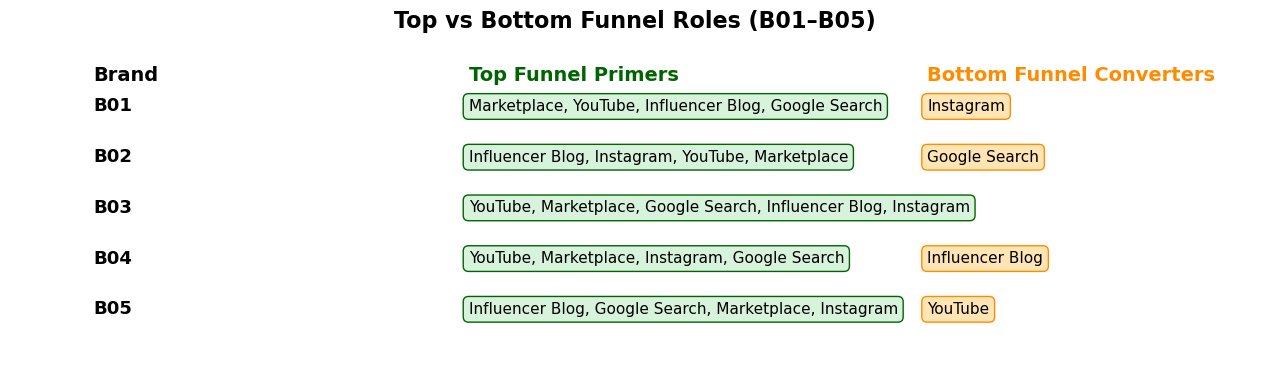

In [143]:
# ==========================================================
# FUNNEL ROLE CARD (B01 - B05)
# ==========================================================

import matplotlib.pyplot as plt

first = funnel_summary.iloc[:5]

fig, ax = plt.subplots(figsize=(13,3.8))
ax.set_xlim(0,3)
ax.set_ylim(0,len(first)+1)
ax.axis("off")

# Header
ax.text(0.2, len(first)+0.5, "Brand",
        fontsize=14, fontweight="bold")

ax.text(1.1, len(first)+0.5, "Top Funnel Primers",
        fontsize=14, fontweight="bold", color="darkgreen")

ax.text(2.2, len(first)+0.5, "Bottom Funnel Converters",
        fontsize=14, fontweight="bold", color="darkorange")

for i, row in enumerate(first.itertuples()):

    y = len(first)-i

    ax.text(
        0.2, y,
        row.Brand,
        fontsize=13,
        fontweight="bold",
        va="center"
    )

    ax.text(
        1.1, y,
        row._2,
        fontsize=11,
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="#d8f3dc",
            ec="darkgreen"
        )
    )

    ax.text(
        2.2, y,
        row._3,
        fontsize=11,
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="#ffe5b4",
            ec="darkorange"
        )
    )

plt.title(
    "Top vs Bottom Funnel Roles (B01–B05)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "funnel_roles_B01_B05.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

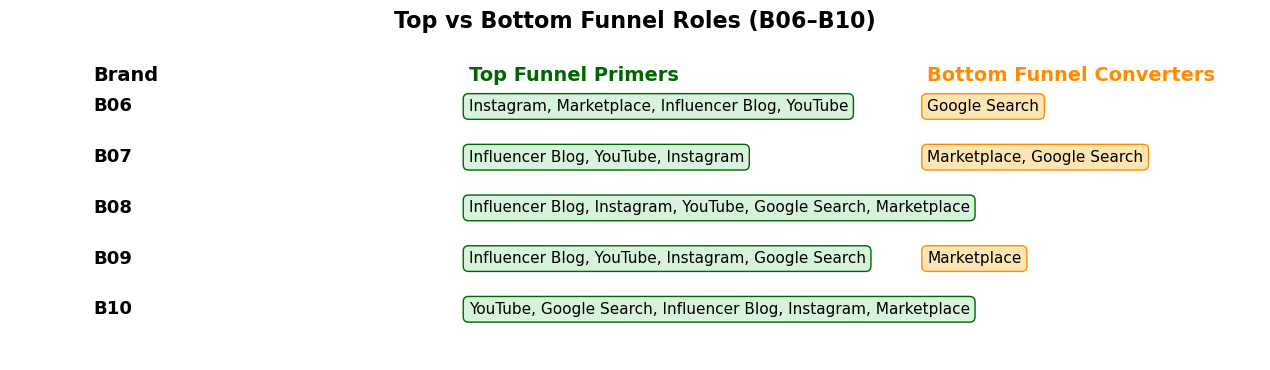

In [144]:
# ==========================================================
# FUNNEL ROLE CARD (B06 - B10)
# ==========================================================

second = funnel_summary.iloc[5:]

fig, ax = plt.subplots(figsize=(13,3.8))
ax.set_xlim(0,3)
ax.set_ylim(0,len(second)+1)
ax.axis("off")

ax.text(0.2, len(second)+0.5, "Brand",
        fontsize=14, fontweight="bold")

ax.text(1.1, len(second)+0.5, "Top Funnel Primers",
        fontsize=14, fontweight="bold", color="darkgreen")

ax.text(2.2, len(second)+0.5, "Bottom Funnel Converters",
        fontsize=14, fontweight="bold", color="darkorange")

for i, row in enumerate(second.itertuples()):

    y = len(second)-i

    ax.text(
        0.2, y,
        row.Brand,
        fontsize=13,
        fontweight="bold",
        va="center"
    )

    ax.text(
        1.1, y,
        row._2,
        fontsize=11,
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="#d8f3dc",
            ec="darkgreen"
        )
    )

    ax.text(
        2.2, y,
        row._3,
        fontsize=11,
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="#ffe5b4",
            ec="darkorange"
        )
    )

plt.title(
    "Top vs Bottom Funnel Roles (B06–B10)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "funnel_roles_B06_B10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

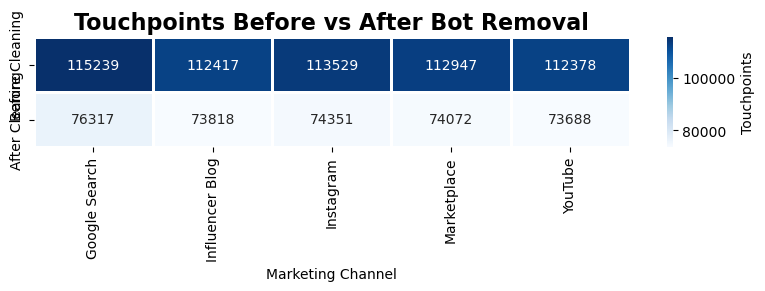

In [145]:
# ==========================================================
# BEFORE VS AFTER BOT CLEANING HEATMAP
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

before = (
    touchpoints
    .groupby("Channel")
    .size()
)

after = (
    touchpoints_clean
    .groupby("Channel")
    .size()
)

heat = (
    pd.concat([before, after], axis=1)
    .fillna(0)
)

heat.columns = [
    "Before Cleaning",
    "After Cleaning"
]

heat = heat.T

plt.figure(figsize=(8,3))

sns.heatmap(
    heat,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label":"Touchpoints"}
)

plt.title(
    "Touchpoints Before vs After Bot Removal",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Marketing Channel")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "before_after_bot_cleaning_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()